In [ ]:
# @title
# ============================================================
# 1. Imports
# ============================================================

# Colab에서 yfinance 없으면 이 줄 주석 해제
# %pip -q install -U yfinance

from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, Iterable, List, Optional, Tuple

import os
import math
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


# ============================================================
# SciPy-free replacements
# ============================================================

class _Norm:
    """Minimal replacement for scipy.stats.norm.cdf."""
    @staticmethod
    def cdf(x):
        arr = np.asarray(x, dtype=float)

        def _scalar_cdf(z):
            return 0.5 * (1.0 + math.erf(float(z) / math.sqrt(2.0)))

        out = np.vectorize(_scalar_cdf)(arr)

        if out.ndim == 0:
            return float(out)

        return out


norm = _Norm()


def gamma(x):
    """Minimal replacement for scipy.special.gamma."""
    return math.gamma(float(x))


def solve_banded(l_and_u, ab, b):
    """
    Minimal replacement for scipy.linalg.solve_banded for tridiagonal systems.

    Only supports:
        solve_banded((1, 1), ab, b)

    ab format:
        ab[0, 1:]  = upper diagonal
        ab[1, :]   = main diagonal
        ab[2, :-1] = lower diagonal
    """
    if tuple(l_and_u) != (1, 1):
        raise NotImplementedError("Only tridiagonal solve_banded((1, 1), ab, b) is supported.")

    ab = np.asarray(ab, dtype=float)
    d = np.asarray(b, dtype=float).copy()

    if ab.ndim != 2 or ab.shape[0] != 3:
        raise ValueError("ab must have shape (3, n).")

    n = ab.shape[1]

    if d.shape[0] != n:
        raise ValueError("b length must match ab.shape[1].")

    lower = ab[2, :-1].copy()
    diag = ab[1, :].copy()
    upper = ab[0, 1:].copy()

    if n == 1:
        if abs(diag[0]) < 1e-14:
            raise np.linalg.LinAlgError("Singular matrix.")
        return d / diag[0]

    # Forward elimination
    for i in range(1, n):
        pivot = diag[i - 1]

        if abs(pivot) < 1e-14:
            raise np.linalg.LinAlgError("Near-zero pivot in tridiagonal solver.")

        factor = lower[i - 1] / pivot
        diag[i] = diag[i] - factor * upper[i - 1]
        d[i] = d[i] - factor * d[i - 1]

    # Back substitution
    x = np.empty(n, dtype=float)

    if abs(diag[-1]) < 1e-14:
        raise np.linalg.LinAlgError("Near-zero final pivot in tridiagonal solver.")

    x[-1] = d[-1] / diag[-1]

    for i in range(n - 2, -1, -1):
        if abs(diag[i]) < 1e-14:
            raise np.linalg.LinAlgError("Near-zero pivot in tridiagonal solver.")

        x[i] = (d[i] - upper[i] * x[i + 1]) / diag[i]

    return x


print("Imports OK")
print("norm.cdf(0) =", norm.cdf(0))
print("gamma(1)   =", gamma(1))

Imports OK
norm.cdf(0) = 0.5
gamma(1)   = 1.0


In [ ]:
# @title
# ============================================================
# 2. Function definitions
# ============================================================

@dataclass
class MarketDataConfig:
    ticker: str = "AAPL"
    period: str = "1y"

    price_source: str = "last"  # "last", "mid", "auto"

    target_dtes: Optional[Tuple[int, ...]] = (
        14, 30, 60, 90, 120, 150, 180, 210, 270, 360
    )
    max_expiries: Optional[int] = None

    max_strikes_per_expiry: int = 8
    min_dte: int = 0
    max_dte: Optional[int] = 365

    moneyness_min: float = 0.70
    moneyness_max: float = 1.30

    max_spread_pct: Optional[float] = None
    min_volume: Optional[int] = None
    min_open_interest: Optional[int] = None

    data_debug: bool = True


@dataclass
class ExperimentConfig:
    r: float = 0.0426
    q: float = 0.0

    alpha_grid_coarse: Tuple[float, ...] = (0.50, 0.75)
    sigma_grid_coarse: Tuple[float, ...] = (0.20, 0.30, 0.40)
    lambda_grid_coarse: Tuple[float, ...] = (0.0, 4.0, 8.0)

    m_scan: int = 25
    n_scan: int = 25

    m_final_coarse: int = 35
    n_final_coarse: int = 35
    m_final: int = 50
    n_final: int = 50

    refine_alpha: bool = True
    alpha_radius: float = 0.10
    alpha_step: float = 0.05

    sigma_radius: float = 0.05
    sigma_step: float = 0.025
    sigma_bounds: Tuple[float, float] = (0.03, 1.20)

    lambda_radius: float = 4.0
    lambda_step: float = 2.0
    lambda_bounds: Tuple[float, float] = (0.0, 40.0)

    smax_mult: float = 3.0

    short_days: int = 30
    medium_days: int = 180

    progress: bool = True


# ============================================================
# Utilities
# ============================================================

def _tup(x):
    return tuple(float(v) for v in x)


def _as_float_array(x: Iterable[float]) -> np.ndarray:
    arr = np.asarray(list(x), dtype=float)
    return arr[np.isfinite(arr)]


def local_grid(center: float, radius: float, step: float, lower: float, upper: float) -> np.ndarray:
    if center is None or not np.isfinite(center):
        return np.array([], dtype=float)

    if step <= 0:
        raise ValueError("step must be positive")

    lo = max(float(lower), float(center) - float(radius))
    hi = min(float(upper), float(center) + float(radius))

    if lo > hi:
        return np.array([], dtype=float)

    grid = np.arange(lo, hi + 0.5 * step, step, dtype=float)
    grid = grid[(grid >= lower - 1e-12) & (grid <= upper + 1e-12)]

    return np.unique(np.round(grid, 10))


def pooled_rmse_from_sse(df: pd.DataFrame, sse_col: str, n_col: str) -> float:
    if df is None or df.empty:
        return np.nan

    total_sse = float(df[sse_col].sum())
    total_n = int(df[n_col].sum())

    if total_n <= 0 or not np.isfinite(total_sse):
        return np.nan

    return float(np.sqrt(total_sse / total_n))


def add_maturity_bucket(
    df: pd.DataFrame,
    short_days: int = 30,
    medium_days: int = 180,
    t_col: str = "T",
) -> pd.DataFrame:
    out = df.copy()
    days = 365.25 * out[t_col].astype(float)

    out["T_days"] = days
    out["bucket"] = np.select(
        [days <= short_days, days <= medium_days],
        ["Short", "Medium"],
        default="Long",
    )

    return out


def _select_expiries_balanced(
    expiry_rows: List[Tuple[str, int, float]],
    target_dtes: Optional[Tuple[int, ...]],
    max_expiries: Optional[int],
) -> List[Tuple[str, int, float]]:
    expiry_rows = sorted(expiry_rows, key=lambda x: x[1])

    if target_dtes is None:
        if max_expiries is not None:
            return expiry_rows[: int(max_expiries)]
        return expiry_rows

    selected: Dict[str, Tuple[str, int, float]] = {}

    for target in target_dtes:
        if len(expiry_rows) == 0:
            break

        best = min(expiry_rows, key=lambda x: abs(x[1] - target))
        selected[best[0]] = best

    selected_rows = sorted(selected.values(), key=lambda x: x[1])

    if max_expiries is not None:
        selected_rows = selected_rows[: int(max_expiries)]

    return selected_rows


# ============================================================
# Market data
# ============================================================

def collect_call_options_yfinance(cfg: MarketDataConfig) -> Tuple[float, pd.DataFrame]:
    if cfg.price_source not in {"auto", "mid", "last"}:
        raise ValueError("price_source must be one of: auto, mid, last")

    ticker_obj = yf.Ticker(cfg.ticker)

    hist = ticker_obj.history(period=cfg.period, auto_adjust=False)

    if hist.empty:
        raise RuntimeError(f"No price history returned for {cfg.ticker}")

    S0 = float(hist["Close"].dropna().iloc[-1])

    expiries = list(ticker_obj.options)

    if len(expiries) == 0:
        raise RuntimeError(f"No option expiries returned for {cfg.ticker}")

    today = pd.Timestamp.now(tz="UTC").normalize().tz_localize(None)

    expiry_rows = []

    for exp in expiries:
        exp_ts = pd.Timestamp(exp)
        dte = int((exp_ts - today).days)

        if dte < cfg.min_dte:
            continue

        if cfg.max_dte is not None and dte > cfg.max_dte:
            continue

        expiry_rows.append((exp, dte, dte / 365.25))

    expiry_rows = _select_expiries_balanced(
        expiry_rows,
        target_dtes=cfg.target_dtes,
        max_expiries=cfg.max_expiries,
    )

    if len(expiry_rows) == 0:
        raise RuntimeError("No expiries survived DTE filtering.")

    rows = []
    debug_rows = []

    for exp, dte, T in expiry_rows:
        report = {
            "expiry": exp,
            "dte": dte,
            "raw": 0,
            "moneyness": 0,
            "valid_mid": 0,
            "valid_last": 0,
            "chosen_price": 0,
            "after_liquidity": 0,
            "selected": 0,
        }

        try:
            chain = ticker_obj.option_chain(exp)
            calls = chain.calls.copy()
        except Exception as exc:
            report["error"] = str(exc)
            debug_rows.append(report)
            print(f"[warning] failed option_chain({exp}): {exc}")
            continue

        report["raw"] = int(len(calls))

        if calls.empty:
            debug_rows.append(report)
            continue

        for col in ["bid", "ask", "lastPrice", "volume", "openInterest", "impliedVolatility"]:
            if col not in calls.columns:
                calls[col] = np.nan

        numeric_cols = [
            "strike",
            "bid",
            "ask",
            "lastPrice",
            "volume",
            "openInterest",
            "impliedVolatility",
        ]

        for col in numeric_cols:
            calls[col] = pd.to_numeric(calls[col], errors="coerce")

        calls = calls.dropna(subset=["strike"]).copy()
        calls["strike"] = calls["strike"].astype(float)
        calls["moneyness"] = calls["strike"] / S0

        calls = calls[
            (calls["moneyness"] >= cfg.moneyness_min)
            & (calls["moneyness"] <= cfg.moneyness_max)
        ].copy()

        report["moneyness"] = int(len(calls))

        if calls.empty:
            debug_rows.append(report)
            continue

        calls["mid"] = 0.5 * (calls["bid"] + calls["ask"])
        calls["spread"] = calls["ask"] - calls["bid"]
        calls["spread_pct"] = np.where(calls["mid"] > 0, calls["spread"] / calls["mid"], np.nan)

        valid_mid = (
            (calls["bid"] > 0)
            & (calls["ask"] > 0)
            & (calls["ask"] >= calls["bid"])
            & (calls["mid"] > 0)
        )

        if cfg.max_spread_pct is not None:
            valid_mid = valid_mid & (calls["spread_pct"] <= cfg.max_spread_pct)

        valid_last = calls["lastPrice"] > 0

        calls["valid_mid"] = valid_mid
        calls["valid_last"] = valid_last

        report["valid_mid"] = int(valid_mid.sum())
        report["valid_last"] = int(valid_last.sum())

        if cfg.price_source == "mid":
            calls = calls[calls["valid_mid"]].copy()
            calls["market_price"] = calls["mid"]
            calls["price_type"] = "mid"

        elif cfg.price_source == "last":
            calls = calls[calls["valid_last"]].copy()
            calls["market_price"] = calls["lastPrice"]
            calls["price_type"] = "last"

        else:
            calls = calls[calls["valid_mid"] | calls["valid_last"]].copy()
            calls["market_price"] = np.where(calls["valid_mid"], calls["mid"], calls["lastPrice"])
            calls["price_type"] = np.where(calls["valid_mid"], "mid", "last")

        calls = calls[np.isfinite(calls["market_price"]) & (calls["market_price"] > 0)].copy()

        report["chosen_price"] = int(len(calls))

        if calls.empty:
            debug_rows.append(report)
            continue

        if cfg.min_volume is not None:
            calls["volume"] = calls["volume"].fillna(0)
            calls = calls[calls["volume"] >= cfg.min_volume].copy()

        if cfg.min_open_interest is not None:
            calls["openInterest"] = calls["openInterest"].fillna(0)
            calls = calls[calls["openInterest"] >= cfg.min_open_interest].copy()

        report["after_liquidity"] = int(len(calls))

        if calls.empty:
            debug_rows.append(report)
            continue

        calls["abs_moneyness_gap"] = np.abs(calls["moneyness"] - 1.0)
        calls = calls.sort_values(["abs_moneyness_gap", "strike"]).head(cfg.max_strikes_per_expiry)
        calls = calls.sort_values("strike").reset_index(drop=True)

        report["selected"] = int(len(calls))

        for _, rr in calls.iterrows():
            rows.append(
                {
                    "ticker": cfg.ticker,
                    "expiry": exp,
                    "T": float(T),
                    "T_days": float(dte),
                    "strike": float(rr["strike"]),
                    "market_price": float(rr["market_price"]),
                    "price_type": str(rr["price_type"]),
                    "bid": float(rr["bid"]) if np.isfinite(rr["bid"]) else np.nan,
                    "ask": float(rr["ask"]) if np.isfinite(rr["ask"]) else np.nan,
                    "mid": float(rr["mid"]) if np.isfinite(rr["mid"]) else np.nan,
                    "lastPrice": float(rr["lastPrice"]) if np.isfinite(rr["lastPrice"]) else np.nan,
                    "spread": float(rr["spread"]) if np.isfinite(rr["spread"]) else np.nan,
                    "spread_pct": float(rr["spread_pct"]) if np.isfinite(rr["spread_pct"]) else np.nan,
                    "impliedVolatility": float(rr["impliedVolatility"])
                    if np.isfinite(rr["impliedVolatility"])
                    else np.nan,
                    "volume": float(rr["volume"]) if np.isfinite(rr["volume"]) else np.nan,
                    "openInterest": float(rr["openInterest"])
                    if np.isfinite(rr["openInterest"])
                    else np.nan,
                    "moneyness": float(rr["moneyness"]),
                }
            )

        debug_rows.append(report)

    debug_df = pd.DataFrame(debug_rows)

    if cfg.data_debug and not debug_df.empty:
        print("\n[yfinance option filter report]")
        print(debug_df.to_string(index=False))

    df = pd.DataFrame(rows)

    if df.empty:
        raise RuntimeError(
            "No option rows survived filtering. Try price_source='last', "
            "wider moneyness range, max_spread_pct=None, or larger max_dte."
        )

    df = df.sort_values(["T", "expiry", "strike"]).reset_index(drop=True)

    return S0, df


# ============================================================
# Train-validation split
# ============================================================

def split_by_expiry_alternating(
    df: pd.DataFrame,
    min_contracts_per_expiry: int = 4,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    train_parts = []
    val_parts = []

    df0 = df.sort_values(["T", "expiry", "strike"]).reset_index(drop=True)

    for _, sub in df0.groupby("expiry", sort=False):
        sub = sub.sort_values("strike").reset_index(drop=True)

        if len(sub) < min_contracts_per_expiry:
            continue

        train = sub.iloc[::2].copy()
        val = sub.iloc[1::2].copy()

        if len(train) == 0 or len(val) == 0:
            continue

        train_parts.append(train)
        val_parts.append(val)

    if not train_parts or not val_parts:
        raise RuntimeError(
            "Train-validation split failed. Increase max_strikes_per_expiry or loosen filters."
        )

    df_train = pd.concat(train_parts, ignore_index=True)
    df_val = pd.concat(val_parts, ignore_index=True)

    df_train = df_train.sort_values(["T", "expiry", "strike"]).reset_index(drop=True)
    df_val = df_val.sort_values(["T", "expiry", "strike"]).reset_index(drop=True)

    return df_train, df_val


# ============================================================
# Black-Scholes
# ============================================================

def bs_call_price(
    S0: float,
    K: float,
    T: float,
    r: float,
    sigma: float,
    q: float = 0.0,
) -> float:
    S0 = float(S0)
    K = float(K)
    T = float(T)
    r = float(r)
    sigma = float(sigma)
    q = float(q)

    if T <= 0:
        return max(S0 - K, 0.0)

    if S0 <= 0 or K <= 0:
        return np.nan

    if sigma <= 0 or not np.isfinite(sigma):
        return max(S0 * math.exp(-q * T) - K * math.exp(-r * T), 0.0)

    vol_sqrt = sigma * math.sqrt(T)

    d1 = (math.log(S0 / K) + (r - q + 0.5 * sigma * sigma) * T) / vol_sqrt
    d2 = d1 - vol_sqrt

    price = S0 * math.exp(-q * T) * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)

    return float(price)


def fit_bs_per_expiry(
    S0: float,
    df_cal: pd.DataFrame,
    r: float,
    q: float,
    sigma_grid: Iterable[float],
) -> pd.DataFrame:
    grid = _as_float_array(sigma_grid)
    grid = grid[grid > 0]

    if grid.size == 0:
        raise ValueError("sigma_grid is empty")

    rows = []

    for expiry, sub in df_cal.groupby("expiry", sort=False):
        T = float(sub["T"].iloc[0])
        Ks = sub["strike"].to_numpy(dtype=float)
        y = sub["market_price"].to_numpy(dtype=float)

        best_sigma = np.nan
        best_sse = np.inf

        for sigma in grid:
            pred = np.array([bs_call_price(S0, K, T, r, sigma, q=q) for K in Ks])

            if np.any(~np.isfinite(pred)):
                continue

            sse = float(np.sum((y - pred) ** 2))

            if sse < best_sse:
                best_sse = sse
                best_sigma = float(sigma)

        n = len(sub)

        rows.append(
            {
                "expiry": expiry,
                "T": T,
                "n_cal": n,
                "best_sigma_BS": best_sigma,
                "SSE_cal_BS": best_sse,
                "RMSE_cal_BS": float(np.sqrt(best_sse / n)) if np.isfinite(best_sse) else np.nan,
            }
        )

    return pd.DataFrame(rows).sort_values("T").reset_index(drop=True)


def fit_bs_coarse_to_fine(
    S0: float,
    df_cal: pd.DataFrame,
    r: float,
    q: float,
    sigma_grid_coarse: Iterable[float],
    sigma_radius: float,
    sigma_step: float,
    sigma_bounds: Tuple[float, float],
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df_coarse = fit_bs_per_expiry(S0, df_cal, r, q, sigma_grid_coarse)

    fine_parts = []

    for _, row in df_coarse.iterrows():
        expiry = row["expiry"]
        sigma0 = float(row["best_sigma_BS"])
        sub = df_cal[df_cal["expiry"] == expiry]

        fine_grid = local_grid(
            center=sigma0,
            radius=sigma_radius,
            step=sigma_step,
            lower=sigma_bounds[0],
            upper=sigma_bounds[1],
        )

        if fine_grid.size == 0:
            fine_parts.append(pd.DataFrame([row]))
        else:
            fine_parts.append(fit_bs_per_expiry(S0, sub, r, q, fine_grid))

    df_fine = pd.concat(fine_parts, ignore_index=True)

    return df_fine.sort_values("T").reset_index(drop=True), df_coarse


def evaluate_bs_per_expiry(
    S0: float,
    df_val: pd.DataFrame,
    r: float,
    q: float,
    df_bs_fit: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    for _, fit_row in df_bs_fit.iterrows():
        expiry = fit_row["expiry"]
        sigma = float(fit_row["best_sigma_BS"])

        if not np.isfinite(sigma):
            continue

        sub = df_val[df_val["expiry"] == expiry]

        if sub.empty:
            continue

        T = float(sub["T"].iloc[0])
        Ks = sub["strike"].to_numpy(dtype=float)
        y = sub["market_price"].to_numpy(dtype=float)

        pred = np.array([bs_call_price(S0, K, T, r, sigma, q=q) for K in Ks])

        if np.any(~np.isfinite(pred)):
            continue

        sse = float(np.sum((y - pred) ** 2))
        n = len(sub)

        rows.append(
            {
                "expiry": expiry,
                "T": T,
                "n_val": n,
                "SSE_val_BS": sse,
                "RMSE_val_BS": float(np.sqrt(sse / n)),
            }
        )

    return pd.DataFrame(rows).sort_values("T").reset_index(drop=True)


# ============================================================
# TFBS pricer
# ============================================================

def caputo_tempered_weights(
    alpha: float,
    lam: float,
    N: int,
    dt: float,
) -> Tuple[np.ndarray, np.ndarray, float]:
    alpha = float(alpha)
    lam = float(lam)
    N = int(N)
    dt = float(dt)

    if not (0.0 < alpha < 1.0):
        raise ValueError("alpha must be in (0, 1)")
    if lam < 0:
        raise ValueError("lambda must be nonnegative")
    if N < 1:
        raise ValueError("N must be >= 1")
    if dt <= 0:
        raise ValueError("dt must be positive")

    k = np.arange(N + 1, dtype=float)

    w = (k + 1.0) ** (1.0 - alpha) - k ** (1.0 - alpha)
    damp = np.exp(-lam * k * dt)
    coef0 = 1.0 / ((dt ** alpha) * gamma(2.0 - alpha))

    return w, damp, float(coef0)


def build_bs_operator_coefficients(
    S: np.ndarray,
    r: float,
    q: float,
    sigma: float,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    dS = float(S[1] - S[0])
    Sj = S[1:-1]

    drift = r - q

    a = 0.5 * sigma * sigma * Sj * Sj / (dS * dS) - 0.5 * drift * Sj / dS
    b = -sigma * sigma * Sj * Sj / (dS * dS) - r
    c = 0.5 * sigma * sigma * Sj * Sj / (dS * dS) + 0.5 * drift * Sj / dS

    return a, b, c


def tfbs_call_price(
    S0: float,
    K: float,
    T: float,
    r: float,
    q: float,
    sigma: float,
    alpha: float,
    lam: float,
    M: int = 50,
    N: int = 50,
    smax_mult: float = 3.0,
    pre_weights: Optional[Tuple[np.ndarray, np.ndarray, float]] = None,
) -> float:
    S0 = float(S0)
    K = float(K)
    T = float(T)
    r = float(r)
    q = float(q)
    sigma = float(sigma)
    alpha = float(alpha)
    lam = float(lam)
    M = int(M)
    N = int(N)

    if T <= 0:
        return max(S0 - K, 0.0)

    if S0 <= 0 or K <= 0 or sigma <= 0:
        return np.nan

    if not (0.0 < alpha < 1.0):
        return np.nan

    if lam < 0:
        return np.nan

    if M < 3 or N < 1:
        raise ValueError("Need M >= 3 and N >= 1")

    Smax = float(smax_mult) * max(S0, K)
    S = np.linspace(0.0, Smax, M + 1)
    dt = T / N

    if pre_weights is None:
        w, damp, coef0 = caputo_tempered_weights(alpha, lam, N, dt)
    else:
        w, damp, coef0 = pre_weights

    a, b, c = build_bs_operator_coefficients(S, r, q, sigma)

    n_inner = M - 1

    diag = coef0 - b
    lower = -a[1:]
    upper = -c[:-1]

    ab = np.zeros((3, n_inner), dtype=float)
    ab[0, 1:] = upper
    ab[1, :] = diag
    ab[2, :-1] = lower

    C = np.zeros((M + 1, N + 1), dtype=float)

    C[:, 0] = np.maximum(S - K, 0.0)
    C[0, :] = 0.0

    for n in range(N):
        tau_next = (n + 1) * dt

        C_left = 0.0
        C_right = max(Smax * math.exp(-q * tau_next) - K * math.exp(-r * tau_next), 0.0)

        old_inner = C[1:M, n]

        if n == 0:
            hist = np.zeros(n_inner, dtype=float)
        else:
            diffs = C[1:M, 1 : n + 1] - C[1:M, 0:n]
            hist_weights = (w[1 : n + 1] * damp[1 : n + 1])[::-1]
            hist = np.sum(diffs * hist_weights[None, :], axis=1)

        rhs = coef0 * old_inner - coef0 * hist

        rhs[0] += a[0] * C_left
        rhs[-1] += c[-1] * C_right

        new_inner = solve_banded((1, 1), ab, rhs)

        C[0, n + 1] = C_left
        C[1:M, n + 1] = new_inner
        C[M, n + 1] = C_right

    return float(np.interp(S0, S, C[:, -1]))


# ============================================================
# TFBS fitting
# ============================================================

def fit_tfbs_per_expiry(
    S0: float,
    df_cal: pd.DataFrame,
    r: float,
    q: float,
    alpha: float,
    sigma_grid: Iterable[float],
    lambda_grid: Iterable[float],
    M: int,
    N: int,
    smax_mult: float,
) -> pd.DataFrame:
    sigma_grid_arr = _as_float_array(sigma_grid)
    sigma_grid_arr = sigma_grid_arr[sigma_grid_arr > 0]

    lambda_grid_arr = _as_float_array(lambda_grid)
    lambda_grid_arr = lambda_grid_arr[lambda_grid_arr >= 0]

    if sigma_grid_arr.size == 0:
        raise ValueError("sigma_grid is empty")
    if lambda_grid_arr.size == 0:
        raise ValueError("lambda_grid is empty")

    weights_cache: Dict[Tuple[float, float], Tuple[np.ndarray, np.ndarray, float]] = {}

    def get_weights(T: float, lam: float) -> Tuple[np.ndarray, np.ndarray, float]:
        key = (float(T), float(lam))

        if key not in weights_cache:
            dt = float(T) / int(N)
            weights_cache[key] = caputo_tempered_weights(alpha, lam, int(N), dt)

        return weights_cache[key]

    rows = []

    for expiry, sub in df_cal.groupby("expiry", sort=False):
        T = float(sub["T"].iloc[0])
        Ks = sub["strike"].to_numpy(dtype=float)
        y = sub["market_price"].to_numpy(dtype=float)

        best_sigma = np.nan
        best_lambda = np.nan
        best_sse = np.inf

        for lam in lambda_grid_arr:
            pre_weights = get_weights(T, float(lam))

            for sigma in sigma_grid_arr:
                pred = np.array(
                    [
                        tfbs_call_price(
                            S0=S0,
                            K=K,
                            T=T,
                            r=r,
                            q=q,
                            sigma=float(sigma),
                            alpha=float(alpha),
                            lam=float(lam),
                            M=M,
                            N=N,
                            smax_mult=smax_mult,
                            pre_weights=pre_weights,
                        )
                        for K in Ks
                    ],
                    dtype=float,
                )

                if np.any(~np.isfinite(pred)):
                    continue

                sse = float(np.sum((y - pred) ** 2))

                if sse < best_sse:
                    best_sse = sse
                    best_sigma = float(sigma)
                    best_lambda = float(lam)

        n = len(sub)

        rows.append(
            {
                "expiry": expiry,
                "T": T,
                "n_cal": n,
                "alpha": float(alpha),
                "best_sigma_TFBS": best_sigma,
                "best_lambda_TFBS": best_lambda,
                "SSE_cal_TFBS": best_sse,
                "RMSE_cal_TFBS": float(np.sqrt(best_sse / n)) if np.isfinite(best_sse) else np.nan,
            }
        )

    return pd.DataFrame(rows).sort_values("T").reset_index(drop=True)


def scan_alpha_on_calibration(
    S0: float,
    df_cal: pd.DataFrame,
    r: float,
    q: float,
    alpha_grid: Iterable[float],
    sigma_grid: Iterable[float],
    lambda_grid: Iterable[float],
    M: int,
    N: int,
    smax_mult: float,
    stage: str,
    progress: bool = True,
) -> pd.DataFrame:
    rows = []

    for alpha in _as_float_array(alpha_grid):
        if not (0.0 < float(alpha) < 1.0):
            continue

        if progress:
            print(f"[alpha scan:{stage}] alpha={alpha:.4f}")

        df_fit = fit_tfbs_per_expiry(
            S0=S0,
            df_cal=df_cal,
            r=r,
            q=q,
            alpha=float(alpha),
            sigma_grid=sigma_grid,
            lambda_grid=lambda_grid,
            M=M,
            N=N,
            smax_mult=smax_mult,
        )

        rows.append(
            {
                "stage": stage,
                "alpha": float(alpha),
                "pooled_cal_RMSE_TFBS": pooled_rmse_from_sse(
                    df_fit,
                    "SSE_cal_TFBS",
                    "n_cal",
                ),
                "n_expiries": int(df_fit["expiry"].nunique()),
                "n_cal_total": int(df_fit["n_cal"].sum()),
            }
        )

    if not rows:
        raise RuntimeError("alpha scan produced no rows")

    return pd.DataFrame(rows).sort_values("pooled_cal_RMSE_TFBS").reset_index(drop=True)


def fit_tfbs_coarse_to_fine(
    S0: float,
    df_cal: pd.DataFrame,
    r: float,
    q: float,
    alpha: float,
    sigma_grid_coarse: Iterable[float],
    lambda_grid_coarse: Iterable[float],
    M_coarse: int,
    N_coarse: int,
    M_fine: int,
    N_fine: int,
    smax_mult: float,
    sigma_radius: float,
    sigma_step: float,
    sigma_bounds: Tuple[float, float],
    lambda_radius: float,
    lambda_step: float,
    lambda_bounds: Tuple[float, float],
    progress: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df_coarse = fit_tfbs_per_expiry(
        S0=S0,
        df_cal=df_cal,
        r=r,
        q=q,
        alpha=alpha,
        sigma_grid=sigma_grid_coarse,
        lambda_grid=lambda_grid_coarse,
        M=M_coarse,
        N=N_coarse,
        smax_mult=smax_mult,
    )

    fine_parts = []

    for _, row in df_coarse.iterrows():
        expiry = row["expiry"]
        sigma0 = float(row["best_sigma_TFBS"])
        lambda0 = float(row["best_lambda_TFBS"])

        sub = df_cal[df_cal["expiry"] == expiry]

        sigma_grid_fine = local_grid(
            sigma0,
            sigma_radius,
            sigma_step,
            sigma_bounds[0],
            sigma_bounds[1],
        )

        lambda_grid_fine = local_grid(
            lambda0,
            lambda_radius,
            lambda_step,
            lambda_bounds[0],
            lambda_bounds[1],
        )

        if progress:
            print(
                f"[TFBS local fine] {expiry}: "
                f"sigma0={sigma0:.4f}, lambda0={lambda0:.4f}, "
                f"grid={len(sigma_grid_fine)}x{len(lambda_grid_fine)}"
            )

        if sigma_grid_fine.size == 0 or lambda_grid_fine.size == 0:
            fine_parts.append(pd.DataFrame([row]))
        else:
            fine_parts.append(
                fit_tfbs_per_expiry(
                    S0=S0,
                    df_cal=sub,
                    r=r,
                    q=q,
                    alpha=alpha,
                    sigma_grid=sigma_grid_fine,
                    lambda_grid=lambda_grid_fine,
                    M=M_fine,
                    N=N_fine,
                    smax_mult=smax_mult,
                )
            )

    df_fine = pd.concat(fine_parts, ignore_index=True)

    return df_fine.sort_values("T").reset_index(drop=True), df_coarse


def evaluate_tfbs_per_expiry(
    S0: float,
    df_val: pd.DataFrame,
    r: float,
    q: float,
    df_tfbs_fit: pd.DataFrame,
    M: int,
    N: int,
    smax_mult: float,
) -> pd.DataFrame:
    weights_cache: Dict[Tuple[float, float, float], Tuple[np.ndarray, np.ndarray, float]] = {}

    def get_weights(T: float, alpha: float, lam: float) -> Tuple[np.ndarray, np.ndarray, float]:
        key = (float(T), float(alpha), float(lam))

        if key not in weights_cache:
            dt = float(T) / int(N)
            weights_cache[key] = caputo_tempered_weights(alpha, lam, int(N), dt)

        return weights_cache[key]

    rows = []

    for _, fit_row in df_tfbs_fit.iterrows():
        expiry = fit_row["expiry"]
        alpha = float(fit_row["alpha"])
        sigma = float(fit_row["best_sigma_TFBS"])
        lam = float(fit_row["best_lambda_TFBS"])

        if not (np.isfinite(alpha) and np.isfinite(sigma) and np.isfinite(lam)):
            continue

        sub = df_val[df_val["expiry"] == expiry]

        if sub.empty:
            continue

        T = float(sub["T"].iloc[0])
        Ks = sub["strike"].to_numpy(dtype=float)
        y = sub["market_price"].to_numpy(dtype=float)

        pre_weights = get_weights(T, alpha, lam)

        pred = np.array(
            [
                tfbs_call_price(
                    S0=S0,
                    K=K,
                    T=T,
                    r=r,
                    q=q,
                    sigma=sigma,
                    alpha=alpha,
                    lam=lam,
                    M=M,
                    N=N,
                    smax_mult=smax_mult,
                    pre_weights=pre_weights,
                )
                for K in Ks
            ],
            dtype=float,
        )

        if np.any(~np.isfinite(pred)):
            continue

        sse = float(np.sum((y - pred) ** 2))
        n = len(sub)

        rows.append(
            {
                "expiry": expiry,
                "T": T,
                "n_val": n,
                "SSE_val_TFBS": sse,
                "RMSE_val_TFBS": float(np.sqrt(sse / n)),
            }
        )

    return pd.DataFrame(rows).sort_values("T").reset_index(drop=True)


# ============================================================
# Driver
# ============================================================

def summarize_validation_by_bucket(
    df_compare: pd.DataFrame,
    short_days: int,
    medium_days: int,
) -> pd.DataFrame:
    if df_compare.empty:
        return pd.DataFrame()

    df0 = add_maturity_bucket(
        df_compare,
        short_days=short_days,
        medium_days=medium_days,
    )

    rows = []

    for bucket in ["Short", "Medium", "Long"]:
        sub = df0[df0["bucket"] == bucket]

        if sub.empty:
            continue

        n = int(sub["n_val"].sum())

        if n <= 0:
            continue

        rmse_bs = float(np.sqrt(sub["SSE_val_BS"].sum() / n))
        rmse_tfbs = float(np.sqrt(sub["SSE_val_TFBS"].sum() / n))

        rows.append(
            {
                "bucket": bucket,
                "n_expiries": int(sub["expiry"].nunique()),
                "n_val": n,
                "RMSE_val_BS": rmse_bs,
                "RMSE_val_TFBS": rmse_tfbs,
                "improvement_pct": 100.0 * (rmse_bs - rmse_tfbs) / rmse_bs
                if rmse_bs > 0
                else np.nan,
            }
        )

    n_all = int(df0["n_val"].sum())

    if n_all > 0:
        rmse_bs = float(np.sqrt(df0["SSE_val_BS"].sum() / n_all))
        rmse_tfbs = float(np.sqrt(df0["SSE_val_TFBS"].sum() / n_all))

        rows.append(
            {
                "bucket": "All",
                "n_expiries": int(df0["expiry"].nunique()),
                "n_val": n_all,
                "RMSE_val_BS": rmse_bs,
                "RMSE_val_TFBS": rmse_tfbs,
                "improvement_pct": 100.0 * (rmse_bs - rmse_tfbs) / rmse_bs
                if rmse_bs > 0
                else np.nan,
            }
        )

    return pd.DataFrame(rows)


def run_tfbs_experiment(
    market_cfg: MarketDataConfig,
    exp_cfg: ExperimentConfig,
    df_options: Optional[pd.DataFrame] = None,
    S0: Optional[float] = None,
) -> Dict[str, Any]:
    if df_options is None:
        S0_used, df_all = collect_call_options_yfinance(market_cfg)
    else:
        if S0 is None:
            raise ValueError("S0 must be provided when df_options is provided")

        S0_used = float(S0)
        df_all = df_options.copy()

    required_cols = {"expiry", "T", "strike", "market_price"}
    missing = required_cols.difference(df_all.columns)

    if missing:
        raise ValueError(f"df_options missing columns: {sorted(missing)}")

    df_all = df_all.sort_values(["T", "expiry", "strike"]).reset_index(drop=True)
    df_train, df_val = split_by_expiry_alternating(df_all)

    if exp_cfg.progress:
        print("=" * 72)
        print(f"ticker={market_cfg.ticker}, S0={S0_used:.4f}")
        print(f"rows: all={len(df_all)}, calibration={len(df_train)}, validation={len(df_val)}")
        print(f"expiries used={df_all['expiry'].nunique()}")
        print("=" * 72)

    sigma_grid_coarse = np.asarray(exp_cfg.sigma_grid_coarse, dtype=float)
    lambda_grid_coarse = np.asarray(exp_cfg.lambda_grid_coarse, dtype=float)
    alpha_grid_coarse = np.asarray(exp_cfg.alpha_grid_coarse, dtype=float)

    # BS benchmark
    df_bs_fit, df_bs_coarse = fit_bs_coarse_to_fine(
        S0=S0_used,
        df_cal=df_train,
        r=exp_cfg.r,
        q=exp_cfg.q,
        sigma_grid_coarse=sigma_grid_coarse,
        sigma_radius=exp_cfg.sigma_radius,
        sigma_step=exp_cfg.sigma_step,
        sigma_bounds=exp_cfg.sigma_bounds,
    )

    df_bs_val = evaluate_bs_per_expiry(
        S0=S0_used,
        df_val=df_val,
        r=exp_cfg.r,
        q=exp_cfg.q,
        df_bs_fit=df_bs_fit,
    )

    pooled_val_rmse_bs = pooled_rmse_from_sse(df_bs_val, "SSE_val_BS", "n_val")

    # Alpha scan
    df_alpha_coarse = scan_alpha_on_calibration(
        S0=S0_used,
        df_cal=df_train,
        r=exp_cfg.r,
        q=exp_cfg.q,
        alpha_grid=alpha_grid_coarse,
        sigma_grid=sigma_grid_coarse,
        lambda_grid=lambda_grid_coarse,
        M=exp_cfg.m_scan,
        N=exp_cfg.n_scan,
        smax_mult=exp_cfg.smax_mult,
        stage="coarse",
        progress=exp_cfg.progress,
    )

    best_alpha_coarse = float(df_alpha_coarse.iloc[0]["alpha"])

    if exp_cfg.refine_alpha:
        alpha_grid_local = local_grid(
            center=best_alpha_coarse,
            radius=exp_cfg.alpha_radius,
            step=exp_cfg.alpha_step,
            lower=0.05,
            upper=0.99,
        )

        df_alpha_local = scan_alpha_on_calibration(
            S0=S0_used,
            df_cal=df_train,
            r=exp_cfg.r,
            q=exp_cfg.q,
            alpha_grid=alpha_grid_local,
            sigma_grid=sigma_grid_coarse,
            lambda_grid=lambda_grid_coarse,
            M=exp_cfg.m_scan,
            N=exp_cfg.n_scan,
            smax_mult=exp_cfg.smax_mult,
            stage="local",
            progress=exp_cfg.progress,
        )

        df_alpha_scan = pd.concat([df_alpha_coarse, df_alpha_local], ignore_index=True)
        best_alpha = float(df_alpha_local.iloc[0]["alpha"])

    else:
        alpha_grid_local = np.array([], dtype=float)
        df_alpha_scan = df_alpha_coarse.copy()
        best_alpha = best_alpha_coarse

    if exp_cfg.progress:
        print("-" * 72)
        print(f"best_alpha_coarse = {best_alpha_coarse:.4f}")
        print(f"best_alpha_final  = {best_alpha:.4f}")
        print("-" * 72)

    # Final TFBS
    df_tfbs_fit, df_tfbs_coarse = fit_tfbs_coarse_to_fine(
        S0=S0_used,
        df_cal=df_train,
        r=exp_cfg.r,
        q=exp_cfg.q,
        alpha=best_alpha,
        sigma_grid_coarse=sigma_grid_coarse,
        lambda_grid_coarse=lambda_grid_coarse,
        M_coarse=exp_cfg.m_final_coarse,
        N_coarse=exp_cfg.n_final_coarse,
        M_fine=exp_cfg.m_final,
        N_fine=exp_cfg.n_final,
        smax_mult=exp_cfg.smax_mult,
        sigma_radius=exp_cfg.sigma_radius,
        sigma_step=exp_cfg.sigma_step,
        sigma_bounds=exp_cfg.sigma_bounds,
        lambda_radius=exp_cfg.lambda_radius,
        lambda_step=exp_cfg.lambda_step,
        lambda_bounds=exp_cfg.lambda_bounds,
        progress=exp_cfg.progress,
    )

    df_tfbs_val = evaluate_tfbs_per_expiry(
        S0=S0_used,
        df_val=df_val,
        r=exp_cfg.r,
        q=exp_cfg.q,
        df_tfbs_fit=df_tfbs_fit,
        M=exp_cfg.m_final,
        N=exp_cfg.n_final,
        smax_mult=exp_cfg.smax_mult,
    )

    pooled_val_rmse_tfbs = pooled_rmse_from_sse(
        df_tfbs_val,
        "SSE_val_TFBS",
        "n_val",
    )

    # Merge
    df_compare = pd.merge(
        df_bs_fit,
        df_tfbs_fit,
        on=["expiry", "T", "n_cal"],
        how="inner",
    )

    df_compare = pd.merge(
        df_compare,
        df_bs_val,
        on=["expiry", "T"],
        how="inner",
    )

    df_compare = pd.merge(
        df_compare,
        df_tfbs_val,
        on=["expiry", "T", "n_val"],
        how="inner",
    )

    df_compare = add_maturity_bucket(
        df_compare,
        short_days=exp_cfg.short_days,
        medium_days=exp_cfg.medium_days,
    )

    df_compare["RMSE_val_gain"] = df_compare["RMSE_val_BS"] - df_compare["RMSE_val_TFBS"]
    df_compare["RMSE_val_improvement_pct"] = (
        100.0 * df_compare["RMSE_val_gain"] / df_compare["RMSE_val_BS"]
    )

    df_compare = df_compare.sort_values("T").reset_index(drop=True)

    df_summary = summarize_validation_by_bucket(
        df_compare,
        short_days=exp_cfg.short_days,
        medium_days=exp_cfg.medium_days,
    )

    if exp_cfg.progress:
        print("=" * 72)
        print(f"Validation RMSE | BS   = {pooled_val_rmse_bs:.6f}")
        print(f"Validation RMSE | TFBS = {pooled_val_rmse_tfbs:.6f}")
        print("=" * 72)

    return {
        "S0": S0_used,
        "market_cfg": market_cfg,
        "exp_cfg": exp_cfg,
        "best_alpha_coarse": best_alpha_coarse,
        "best_alpha": best_alpha,
        "alpha_grid_local": alpha_grid_local,
        "df_all": df_all,
        "df_train": df_train,
        "df_val": df_val,
        "df_alpha_scan": df_alpha_scan.sort_values(
            ["stage", "pooled_cal_RMSE_TFBS"]
        ).reset_index(drop=True),
        "df_bs_coarse": df_bs_coarse,
        "df_bs_fit": df_bs_fit,
        "df_bs_val": df_bs_val,
        "df_tfbs_coarse": df_tfbs_coarse,
        "df_tfbs_fit": df_tfbs_fit,
        "df_tfbs_val": df_tfbs_val,
        "df_compare_expiry": df_compare,
        "df_validation_summary": df_summary,
        "pooled_val_rmse_bs": pooled_val_rmse_bs,
        "pooled_val_rmse_tfbs": pooled_val_rmse_tfbs,
    }


def diagnose_result(res: Dict[str, Any]) -> None:
    print("\n=== Overall ===")
    print("S0:", res["S0"])
    print("best_alpha_coarse:", res["best_alpha_coarse"])
    print("best_alpha:", res["best_alpha"])
    print("Validation RMSE | BS  :", res["pooled_val_rmse_bs"])
    print("Validation RMSE | TFBS:", res["pooled_val_rmse_tfbs"])

    print("\n=== Bucket summary ===")
    print(res["df_validation_summary"])

    print("\n=== Alpha scan ===")
    print(res["df_alpha_scan"])

    print("\n=== Expiry comparison ===")
    cols = [
        "expiry",
        "T_days",
        "bucket",
        "best_sigma_BS",
        "best_sigma_TFBS",
        "best_lambda_TFBS",
        "RMSE_val_BS",
        "RMSE_val_TFBS",
        "RMSE_val_improvement_pct",
    ]
    cols = [c for c in cols if c in res["df_compare_expiry"].columns]
    print(res["df_compare_expiry"][cols])

    if "price_type" in res["df_all"].columns:
        print("\n=== Price source counts ===")
        print(res["df_all"]["price_type"].value_counts(dropna=False))


# ============================================================
# Simple runner
# ============================================================

GRID_PRESETS = {
    "smoke": {
        "alpha_grid_coarse": _tup([0.50, 0.75]),
        "sigma_grid_coarse": _tup([0.20, 0.30, 0.40]),
        "lambda_grid_coarse": _tup([0.0, 4.0, 8.0]),

        "m_scan": 25,
        "n_scan": 25,
        "m_final_coarse": 35,
        "n_final_coarse": 35,
        "m_final": 50,
        "n_final": 50,

        "refine_alpha": True,
        "alpha_radius": 0.10,
        "alpha_step": 0.05,

        "sigma_radius": 0.05,
        "sigma_step": 0.025,

        "lambda_radius": 4.0,
        "lambda_step": 2.0,
    },

    "coarse": {
        "alpha_grid_coarse": _tup([0.50, 0.65, 0.75, 0.85, 0.95]),
        "sigma_grid_coarse": _tup([0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]),
        "lambda_grid_coarse": _tup([0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0]),

        "m_scan": 30,
        "n_scan": 30,
        "m_final_coarse": 45,
        "n_final_coarse": 45,
        "m_final": 70,
        "n_final": 70,

        "refine_alpha": True,
        "alpha_radius": 0.10,
        "alpha_step": 0.025,

        "sigma_radius": 0.05,
        "sigma_step": 0.02,

        "lambda_radius": 4.0,
        "lambda_step": 1.0,
    },

    "medium": {
        "alpha_grid_coarse": _tup(np.arange(0.45, 0.96, 0.05)),
        "sigma_grid_coarse": _tup(np.arange(0.10, 0.51, 0.05)),
        "lambda_grid_coarse": _tup(np.arange(0.0, 16.1, 2.0)),

        "m_scan": 40,
        "n_scan": 40,
        "m_final_coarse": 60,
        "n_final_coarse": 60,
        "m_final": 90,
        "n_final": 90,

        "refine_alpha": True,
        "alpha_radius": 0.075,
        "alpha_step": 0.025,

        "sigma_radius": 0.05,
        "sigma_step": 0.01,

        "lambda_radius": 3.0,
        "lambda_step": 0.5,
    },
}


def _make_profile_from_grid(GRID):
    if isinstance(GRID, str):
        if GRID not in GRID_PRESETS:
            raise ValueError(f"Unknown GRID preset: {GRID}")
        return GRID_PRESETS[GRID].copy(), GRID

    if isinstance(GRID, dict):
        profile = GRID_PRESETS["smoke"].copy()

        alpha_grid = GRID.get("alpha", GRID.get("alpha_grid_coarse"))
        sigma_grid = GRID.get("sigma", GRID.get("sigma_grid_coarse"))
        lambda_grid = GRID.get("lambda", GRID.get("lam", GRID.get("lambda_grid_coarse")))

        if alpha_grid is None:
            raise ValueError("Custom GRID must contain 'alpha'")
        if sigma_grid is None:
            raise ValueError("Custom GRID must contain 'sigma'")
        if lambda_grid is None:
            raise ValueError("Custom GRID must contain 'lambda'")

        profile["alpha_grid_coarse"] = _tup(alpha_grid)
        profile["sigma_grid_coarse"] = _tup(sigma_grid)
        profile["lambda_grid_coarse"] = _tup(lambda_grid)

        optional_keys = [
            "m_scan",
            "n_scan",
            "m_final_coarse",
            "n_final_coarse",
            "m_final",
            "n_final",
            "refine_alpha",
            "alpha_radius",
            "alpha_step",
            "sigma_radius",
            "sigma_step",
            "sigma_bounds",
            "lambda_radius",
            "lambda_step",
            "lambda_bounds",
        ]

        for key in optional_keys:
            if key in GRID:
                profile[key] = GRID[key]

        return profile, "custom"

    raise TypeError("GRID must be either a preset string or a custom grid dict.")


def _market_setting_from_grid(GRID, key, default):
    if isinstance(GRID, dict) and key in GRID:
        return GRID[key]
    return default


def run_simple_tfbs(TICKER, GRID):
    """
    User-facing runner.

    User controls:
        TICKER: str or list[str]
        GRID: preset string or custom dict
    """
    if isinstance(TICKER, str):
        tickers = [TICKER]
    else:
        tickers = list(TICKER)

    profile, grid_name = _make_profile_from_grid(GRID)

    results = {}
    summary_tables = []
    expiry_tables = []

    print("=" * 80)
    print(f"TICKER(S): {tickers}")
    print(f"GRID     : {grid_name}")
    print("=" * 80)

    print("Grid details:")
    print("alpha :", profile["alpha_grid_coarse"])
    print("sigma :", profile["sigma_grid_coarse"])
    print("lambda:", profile["lambda_grid_coarse"])
    print("=" * 80)

    for ticker in tickers:
        print("\n" + "#" * 80)
        print(f"Running {ticker}")
        print("#" * 80)

        market_cfg = MarketDataConfig(
            ticker=ticker,
            period=_market_setting_from_grid(GRID, "period", "1y"),

            price_source=_market_setting_from_grid(GRID, "price_source", "last"),

            target_dtes=tuple(_market_setting_from_grid(
                GRID,
                "target_dtes",
                (14, 30, 60, 90, 120, 150, 180, 210, 270, 360),
            )),
            max_expiries=_market_setting_from_grid(GRID, "max_expiries", None),

            max_strikes_per_expiry=int(_market_setting_from_grid(GRID, "max_strikes_per_expiry", 8)),

            min_dte=int(_market_setting_from_grid(GRID, "min_dte", 0)),
            max_dte=_market_setting_from_grid(GRID, "max_dte", 365),

            moneyness_min=float(_market_setting_from_grid(GRID, "moneyness_min", 0.70)),
            moneyness_max=float(_market_setting_from_grid(GRID, "moneyness_max", 1.30)),

            max_spread_pct=_market_setting_from_grid(GRID, "max_spread_pct", None),

            min_volume=_market_setting_from_grid(GRID, "min_volume", None),
            min_open_interest=_market_setting_from_grid(GRID, "min_open_interest", None),

            data_debug=bool(_market_setting_from_grid(GRID, "data_debug", True)),
        )

        exp_cfg = ExperimentConfig(
            r=float(_market_setting_from_grid(GRID, "r", 0.0426)),
            q=float(_market_setting_from_grid(GRID, "q", 0.0)),

            alpha_grid_coarse=profile["alpha_grid_coarse"],
            sigma_grid_coarse=profile["sigma_grid_coarse"],
            lambda_grid_coarse=profile["lambda_grid_coarse"],

            m_scan=int(profile["m_scan"]),
            n_scan=int(profile["n_scan"]),

            m_final_coarse=int(profile["m_final_coarse"]),
            n_final_coarse=int(profile["n_final_coarse"]),
            m_final=int(profile["m_final"]),
            n_final=int(profile["n_final"]),

            refine_alpha=bool(profile["refine_alpha"]),
            alpha_radius=float(profile["alpha_radius"]),
            alpha_step=float(profile["alpha_step"]),

            sigma_radius=float(profile["sigma_radius"]),
            sigma_step=float(profile["sigma_step"]),
            sigma_bounds=tuple(profile.get("sigma_bounds", (0.03, 1.20))),

            lambda_radius=float(profile["lambda_radius"]),
            lambda_step=float(profile["lambda_step"]),
            lambda_bounds=tuple(profile.get("lambda_bounds", (0.0, 40.0))),

            short_days=int(_market_setting_from_grid(GRID, "short_days", 30)),
            medium_days=int(_market_setting_from_grid(GRID, "medium_days", 180)),

            progress=bool(_market_setting_from_grid(GRID, "progress", True)),
        )

        try:
            res = run_tfbs_experiment(market_cfg, exp_cfg)
            results[ticker] = res

            diagnose_result(res)

            summary = res["df_validation_summary"].copy()
            summary.insert(0, "ticker", ticker)
            summary.insert(1, "grid", grid_name)
            summary_tables.append(summary)

            expiry = res["df_compare_expiry"].copy()
            expiry.insert(0, "ticker", ticker)
            expiry.insert(1, "grid", grid_name)
            expiry_tables.append(expiry)

        except Exception as exc:
            print(f"[FAILED] {ticker}: {type(exc).__name__}: {exc}")

    summary_all = pd.concat(summary_tables, ignore_index=True) if summary_tables else pd.DataFrame()
    expiry_all = pd.concat(expiry_tables, ignore_index=True) if expiry_tables else pd.DataFrame()

    print("\n" + "=" * 80)
    print("Combined bucket summary")
    print("=" * 80)

    if not summary_all.empty:
        display(summary_all)
    else:
        print("No summary table.")

    print("\n" + "=" * 80)
    print("Combined expiry-level comparison")
    print("=" * 80)

    if not expiry_all.empty:
        cols = [
            "ticker",
            "grid",
            "expiry",
            "T_days",
            "bucket",
            "best_sigma_BS",
            "best_sigma_TFBS",
            "best_lambda_TFBS",
            "RMSE_val_BS",
            "RMSE_val_TFBS",
            "RMSE_val_improvement_pct",
        ]

        cols = [c for c in cols if c in expiry_all.columns]
        display(expiry_all[cols])
    else:
        print("No expiry table.")

    return results, summary_all, expiry_all


print("Function definitions OK")

Function definitions OK


In [ ]:
# @title
# ============================================================
# 2. Function definitions
# ============================================================

@dataclass
class MarketDataConfig:
    ticker: str = "AAPL"
    period: str = "1y"

    price_source: str = "last"  # "last", "mid", "auto"

    target_dtes: Optional[Tuple[int, ...]] = (
        14, 30, 60, 90, 120, 150, 180, 210, 270, 360
    )
    max_expiries: Optional[int] = None

    max_strikes_per_expiry: int = 8
    min_dte: int = 0
    max_dte: Optional[int] = 365

    moneyness_min: float = 0.70
    moneyness_max: float = 1.30

    max_spread_pct: Optional[float] = None
    min_volume: Optional[int] = None
    min_open_interest: Optional[int] = None

    data_debug: bool = True


@dataclass
class ExperimentConfig:
    r: float = 0.0426
    q: float = 0.0

    alpha_grid_coarse: Tuple[float, ...] = (0.50, 0.75)
    sigma_grid_coarse: Tuple[float, ...] = (0.20, 0.30, 0.40)
    lambda_grid_coarse: Tuple[float, ...] = (0.0, 4.0, 8.0)

    m_scan: int = 25
    n_scan: int = 25

    m_final_coarse: int = 35
    n_final_coarse: int = 35
    m_final: int = 50
    n_final: int = 50

    refine_alpha: bool = True
    alpha_radius: float = 0.10
    alpha_step: float = 0.05

    sigma_radius: float = 0.05
    sigma_step: float = 0.025
    sigma_bounds: Tuple[float, float] = (0.03, 1.20)

    lambda_radius: float = 4.0
    lambda_step: float = 2.0
    lambda_bounds: Tuple[float, float] = (0.0, 40.0)

    smax_mult: float = 3.0

    short_days: int = 30
    medium_days: int = 180

    progress: bool = True


# ============================================================
# Utilities
# ============================================================

def _tup(x):
    return tuple(float(v) for v in x)


def _as_float_array(x: Iterable[float]) -> np.ndarray:
    arr = np.asarray(list(x), dtype=float)
    return arr[np.isfinite(arr)]


def local_grid(center: float, radius: float, step: float, lower: float, upper: float) -> np.ndarray:
    if center is None or not np.isfinite(center):
        return np.array([], dtype=float)

    if step <= 0:
        raise ValueError("step must be positive")

    lo = max(float(lower), float(center) - float(radius))
    hi = min(float(upper), float(center) + float(radius))

    if lo > hi:
        return np.array([], dtype=float)

    grid = np.arange(lo, hi + 0.5 * step, step, dtype=float)
    grid = grid[(grid >= lower - 1e-12) & (grid <= upper + 1e-12)]

    return np.unique(np.round(grid, 10))


def pooled_rmse_from_sse(df: pd.DataFrame, sse_col: str, n_col: str) -> float:
    if df is None or df.empty:
        return np.nan

    total_sse = float(df[sse_col].sum())
    total_n = int(df[n_col].sum())

    if total_n <= 0 or not np.isfinite(total_sse):
        return np.nan

    return float(np.sqrt(total_sse / total_n))


def add_maturity_bucket(
    df: pd.DataFrame,
    short_days: int = 30,
    medium_days: int = 180,
    t_col: str = "T",
) -> pd.DataFrame:
    out = df.copy()
    days = 365.25 * out[t_col].astype(float)

    out["T_days"] = days
    out["bucket"] = np.select(
        [days <= short_days, days <= medium_days],
        ["Short", "Medium"],
        default="Long",
    )

    return out


def _select_expiries_balanced(
    expiry_rows: List[Tuple[str, int, float]],
    target_dtes: Optional[Tuple[int, ...]],
    max_expiries: Optional[int],
) -> List[Tuple[str, int, float]]:
    expiry_rows = sorted(expiry_rows, key=lambda x: x[1])

    if target_dtes is None:
        if max_expiries is not None:
            return expiry_rows[: int(max_expiries)]
        return expiry_rows

    selected: Dict[str, Tuple[str, int, float]] = {}

    for target in target_dtes:
        if len(expiry_rows) == 0:
            break

        best = min(expiry_rows, key=lambda x: abs(x[1] - target))
        selected[best[0]] = best

    selected_rows = sorted(selected.values(), key=lambda x: x[1])

    if max_expiries is not None:
        selected_rows = selected_rows[: int(max_expiries)]

    return selected_rows


# ============================================================
# Market data
# ============================================================

def collect_call_options_yfinance(cfg: MarketDataConfig) -> Tuple[float, pd.DataFrame]:
    if cfg.price_source not in {"auto", "mid", "last"}:
        raise ValueError("price_source must be one of: auto, mid, last")

    ticker_obj = yf.Ticker(cfg.ticker)

    hist = ticker_obj.history(period=cfg.period, auto_adjust=False)

    if hist.empty:
        raise RuntimeError(f"No price history returned for {cfg.ticker}")

    S0 = float(hist["Close"].dropna().iloc[-1])

    expiries = list(ticker_obj.options)

    if len(expiries) == 0:
        raise RuntimeError(f"No option expiries returned for {cfg.ticker}")

    today = pd.Timestamp.now(tz="UTC").normalize().tz_localize(None)

    expiry_rows = []

    for exp in expiries:
        exp_ts = pd.Timestamp(exp)
        dte = int((exp_ts - today).days)

        if dte < cfg.min_dte:
            continue

        if cfg.max_dte is not None and dte > cfg.max_dte:
            continue

        expiry_rows.append((exp, dte, dte / 365.25))

    expiry_rows = _select_expiries_balanced(
        expiry_rows,
        target_dtes=cfg.target_dtes,
        max_expiries=cfg.max_expiries,
    )

    if len(expiry_rows) == 0:
        raise RuntimeError("No expiries survived DTE filtering.")

    rows = []
    debug_rows = []

    for exp, dte, T in expiry_rows:
        report = {
            "expiry": exp,
            "dte": dte,
            "raw": 0,
            "moneyness": 0,
            "valid_mid": 0,
            "valid_last": 0,
            "chosen_price": 0,
            "after_liquidity": 0,
            "selected": 0,
        }

        try:
            chain = ticker_obj.option_chain(exp)
            calls = chain.calls.copy()
        except Exception as exc:
            report["error"] = str(exc)
            debug_rows.append(report)
            print(f"[warning] failed option_chain({exp}): {exc}")
            continue

        report["raw"] = int(len(calls))

        if calls.empty:
            debug_rows.append(report)
            continue

        for col in ["bid", "ask", "lastPrice", "volume", "openInterest", "impliedVolatility"]:
            if col not in calls.columns:
                calls[col] = np.nan

        numeric_cols = [
            "strike",
            "bid",
            "ask",
            "lastPrice",
            "volume",
            "openInterest",
            "impliedVolatility",
        ]

        for col in numeric_cols:
            calls[col] = pd.to_numeric(calls[col], errors="coerce")

        calls = calls.dropna(subset=["strike"]).copy()
        calls["strike"] = calls["strike"].astype(float)
        calls["moneyness"] = calls["strike"] / S0

        calls = calls[
            (calls["moneyness"] >= cfg.moneyness_min)
            & (calls["moneyness"] <= cfg.moneyness_max)
        ].copy()

        report["moneyness"] = int(len(calls))

        if calls.empty:
            debug_rows.append(report)
            continue

        calls["mid"] = 0.5 * (calls["bid"] + calls["ask"])
        calls["spread"] = calls["ask"] - calls["bid"]
        calls["spread_pct"] = np.where(calls["mid"] > 0, calls["spread"] / calls["mid"], np.nan)

        valid_mid = (
            (calls["bid"] > 0)
            & (calls["ask"] > 0)
            & (calls["ask"] >= calls["bid"])
            & (calls["mid"] > 0)
        )

        if cfg.max_spread_pct is not None:
            valid_mid = valid_mid & (calls["spread_pct"] <= cfg.max_spread_pct)

        valid_last = calls["lastPrice"] > 0

        calls["valid_mid"] = valid_mid
        calls["valid_last"] = valid_last

        report["valid_mid"] = int(valid_mid.sum())
        report["valid_last"] = int(valid_last.sum())

        if cfg.price_source == "mid":
            calls = calls[calls["valid_mid"]].copy()
            calls["market_price"] = calls["mid"]
            calls["price_type"] = "mid"

        elif cfg.price_source == "last":
            calls = calls[calls["valid_last"]].copy()
            calls["market_price"] = calls["lastPrice"]
            calls["price_type"] = "last"

        else:
            calls = calls[calls["valid_mid"] | calls["valid_last"]].copy()
            calls["market_price"] = np.where(calls["valid_mid"], calls["mid"], calls["lastPrice"])
            calls["price_type"] = np.where(calls["valid_mid"], "mid", "last")

        calls = calls[np.isfinite(calls["market_price"]) & (calls["market_price"] > 0)].copy()

        report["chosen_price"] = int(len(calls))

        if calls.empty:
            debug_rows.append(report)
            continue

        if cfg.min_volume is not None:
            calls["volume"] = calls["volume"].fillna(0)
            calls = calls[calls["volume"] >= cfg.min_volume].copy()

        if cfg.min_open_interest is not None:
            calls["openInterest"] = calls["openInterest"].fillna(0)
            calls = calls[calls["openInterest"] >= cfg.min_open_interest].copy()

        report["after_liquidity"] = int(len(calls))

        if calls.empty:
            debug_rows.append(report)
            continue

        calls["abs_moneyness_gap"] = np.abs(calls["moneyness"] - 1.0)
        calls = calls.sort_values(["abs_moneyness_gap", "strike"]).head(cfg.max_strikes_per_expiry)
        calls = calls.sort_values("strike").reset_index(drop=True)

        report["selected"] = int(len(calls))

        for _, rr in calls.iterrows():
            rows.append(
                {
                    "ticker": cfg.ticker,
                    "expiry": exp,
                    "T": float(T),
                    "T_days": float(dte),
                    "strike": float(rr["strike"]),
                    "market_price": float(rr["market_price"]),
                    "price_type": str(rr["price_type"]),
                    "bid": float(rr["bid"]) if np.isfinite(rr["bid"]) else np.nan,
                    "ask": float(rr["ask"]) if np.isfinite(rr["ask"]) else np.nan,
                    "mid": float(rr["mid"]) if np.isfinite(rr["mid"]) else np.nan,
                    "lastPrice": float(rr["lastPrice"]) if np.isfinite(rr["lastPrice"]) else np.nan,
                    "spread": float(rr["spread"]) if np.isfinite(rr["spread"]) else np.nan,
                    "spread_pct": float(rr["spread_pct"]) if np.isfinite(rr["spread_pct"]) else np.nan,
                    "impliedVolatility": float(rr["impliedVolatility"])
                    if np.isfinite(rr["impliedVolatility"])
                    else np.nan,
                    "volume": float(rr["volume"]) if np.isfinite(rr["volume"]) else np.nan,
                    "openInterest": float(rr["openInterest"])
                    if np.isfinite(rr["openInterest"])
                    else np.nan,
                    "moneyness": float(rr["moneyness"]),
                }
            )

        debug_rows.append(report)

    debug_df = pd.DataFrame(debug_rows)

    if cfg.data_debug and not debug_df.empty:
        print("\n[yfinance option filter report]")
        print(debug_df.to_string(index=False))

    df = pd.DataFrame(rows)

    if df.empty:
        raise RuntimeError(
            "No option rows survived filtering. Try price_source='last', "
            "wider moneyness range, max_spread_pct=None, or larger max_dte."
        )

    df = df.sort_values(["T", "expiry", "strike"]).reset_index(drop=True)

    return S0, df


# ============================================================
# Train-validation split
# ============================================================

def split_by_expiry_alternating(
    df: pd.DataFrame,
    min_contracts_per_expiry: int = 4,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    train_parts = []
    val_parts = []

    df0 = df.sort_values(["T", "expiry", "strike"]).reset_index(drop=True)

    for _, sub in df0.groupby("expiry", sort=False):
        sub = sub.sort_values("strike").reset_index(drop=True)

        if len(sub) < min_contracts_per_expiry:
            continue

        train = sub.iloc[::2].copy()
        val = sub.iloc[1::2].copy()

        if len(train) == 0 or len(val) == 0:
            continue

        train_parts.append(train)
        val_parts.append(val)

    if not train_parts or not val_parts:
        raise RuntimeError(
            "Train-validation split failed. Increase max_strikes_per_expiry or loosen filters."
        )

    df_train = pd.concat(train_parts, ignore_index=True)
    df_val = pd.concat(val_parts, ignore_index=True)

    df_train = df_train.sort_values(["T", "expiry", "strike"]).reset_index(drop=True)
    df_val = df_val.sort_values(["T", "expiry", "strike"]).reset_index(drop=True)

    return df_train, df_val


# ============================================================
# Black-Scholes
# ============================================================

def bs_call_price(
    S0: float,
    K: float,
    T: float,
    r: float,
    sigma: float,
    q: float = 0.0,
) -> float:
    S0 = float(S0)
    K = float(K)
    T = float(T)
    r = float(r)
    sigma = float(sigma)
    q = float(q)

    if T <= 0:
        return max(S0 - K, 0.0)

    if S0 <= 0 or K <= 0:
        return np.nan

    if sigma <= 0 or not np.isfinite(sigma):
        return max(S0 * math.exp(-q * T) - K * math.exp(-r * T), 0.0)

    vol_sqrt = sigma * math.sqrt(T)

    d1 = (math.log(S0 / K) + (r - q + 0.5 * sigma * sigma) * T) / vol_sqrt
    d2 = d1 - vol_sqrt

    price = S0 * math.exp(-q * T) * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)

    return float(price)


def fit_bs_per_expiry(
    S0: float,
    df_cal: pd.DataFrame,
    r: float,
    q: float,
    sigma_grid: Iterable[float],
) -> pd.DataFrame:
    grid = _as_float_array(sigma_grid)
    grid = grid[grid > 0]

    if grid.size == 0:
        raise ValueError("sigma_grid is empty")

    rows = []

    for expiry, sub in df_cal.groupby("expiry", sort=False):
        T = float(sub["T"].iloc[0])
        Ks = sub["strike"].to_numpy(dtype=float)
        y = sub["market_price"].to_numpy(dtype=float)

        best_sigma = np.nan
        best_sse = np.inf

        for sigma in grid:
            pred = np.array([bs_call_price(S0, K, T, r, sigma, q=q) for K in Ks])

            if np.any(~np.isfinite(pred)):
                continue

            sse = float(np.sum((y - pred) ** 2))

            if sse < best_sse:
                best_sse = sse
                best_sigma = float(sigma)

        n = len(sub)

        rows.append(
            {
                "expiry": expiry,
                "T": T,
                "n_cal": n,
                "best_sigma_BS": best_sigma,
                "SSE_cal_BS": best_sse,
                "RMSE_cal_BS": float(np.sqrt(best_sse / n)) if np.isfinite(best_sse) else np.nan,
            }
        )

    return pd.DataFrame(rows).sort_values("T").reset_index(drop=True)


def fit_bs_coarse_to_fine(
    S0: float,
    df_cal: pd.DataFrame,
    r: float,
    q: float,
    sigma_grid_coarse: Iterable[float],
    sigma_radius: float,
    sigma_step: float,
    sigma_bounds: Tuple[float, float],
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df_coarse = fit_bs_per_expiry(S0, df_cal, r, q, sigma_grid_coarse)

    fine_parts = []

    for _, row in df_coarse.iterrows():
        expiry = row["expiry"]
        sigma0 = float(row["best_sigma_BS"])
        sub = df_cal[df_cal["expiry"] == expiry]

        fine_grid = local_grid(
            center=sigma0,
            radius=sigma_radius,
            step=sigma_step,
            lower=sigma_bounds[0],
            upper=sigma_bounds[1],
        )

        if fine_grid.size == 0:
            fine_parts.append(pd.DataFrame([row]))
        else:
            fine_parts.append(fit_bs_per_expiry(S0, sub, r, q, fine_grid))

    df_fine = pd.concat(fine_parts, ignore_index=True)

    return df_fine.sort_values("T").reset_index(drop=True), df_coarse


def evaluate_bs_per_expiry(
    S0: float,
    df_val: pd.DataFrame,
    r: float,
    q: float,
    df_bs_fit: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    for _, fit_row in df_bs_fit.iterrows():
        expiry = fit_row["expiry"]
        sigma = float(fit_row["best_sigma_BS"])

        if not np.isfinite(sigma):
            continue

        sub = df_val[df_val["expiry"] == expiry]

        if sub.empty:
            continue

        T = float(sub["T"].iloc[0])
        Ks = sub["strike"].to_numpy(dtype=float)
        y = sub["market_price"].to_numpy(dtype=float)

        pred = np.array([bs_call_price(S0, K, T, r, sigma, q=q) for K in Ks])

        if np.any(~np.isfinite(pred)):
            continue

        sse = float(np.sum((y - pred) ** 2))
        n = len(sub)

        rows.append(
            {
                "expiry": expiry,
                "T": T,
                "n_val": n,
                "SSE_val_BS": sse,
                "RMSE_val_BS": float(np.sqrt(sse / n)),
            }
        )

    return pd.DataFrame(rows).sort_values("T").reset_index(drop=True)


# ============================================================
# TFBS pricer
# ============================================================

def caputo_tempered_weights(
    alpha: float,
    lam: float,
    N: int,
    dt: float,
) -> Tuple[np.ndarray, np.ndarray, float]:
    alpha = float(alpha)
    lam = float(lam)
    N = int(N)
    dt = float(dt)

    if not (0.0 < alpha < 1.0):
        raise ValueError("alpha must be in (0, 1)")
    if lam < 0:
        raise ValueError("lambda must be nonnegative")
    if N < 1:
        raise ValueError("N must be >= 1")
    if dt <= 0:
        raise ValueError("dt must be positive")

    k = np.arange(N + 1, dtype=float)

    w = (k + 1.0) ** (1.0 - alpha) - k ** (1.0 - alpha)
    damp = np.exp(-lam * k * dt)
    coef0 = 1.0 / ((dt ** alpha) * gamma(2.0 - alpha))

    return w, damp, float(coef0)


def build_bs_operator_coefficients(
    S: np.ndarray,
    r: float,
    q: float,
    sigma: float,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    dS = float(S[1] - S[0])
    Sj = S[1:-1]

    drift = r - q

    a = 0.5 * sigma * sigma * Sj * Sj / (dS * dS) - 0.5 * drift * Sj / dS
    b = -sigma * sigma * Sj * Sj / (dS * dS) - r
    c = 0.5 * sigma * sigma * Sj * Sj / (dS * dS) + 0.5 * drift * Sj / dS

    return a, b, c


def tfbs_call_price(
    S0: float,
    K: float,
    T: float,
    r: float,
    q: float,
    sigma: float,
    alpha: float,
    lam: float,
    M: int = 50,
    N: int = 50,
    smax_mult: float = 3.0,
    pre_weights: Optional[Tuple[np.ndarray, np.ndarray, float]] = None,
) -> float:
    S0 = float(S0)
    K = float(K)
    T = float(T)
    r = float(r)
    q = float(q)
    sigma = float(sigma)
    alpha = float(alpha)
    lam = float(lam)
    M = int(M)
    N = int(N)

    if T <= 0:
        return max(S0 - K, 0.0)

    if S0 <= 0 or K <= 0 or sigma <= 0:
        return np.nan

    if not (0.0 < alpha < 1.0):
        return np.nan

    if lam < 0:
        return np.nan

    if M < 3 or N < 1:
        raise ValueError("Need M >= 3 and N >= 1")

    Smax = float(smax_mult) * max(S0, K)
    S = np.linspace(0.0, Smax, M + 1)
    dt = T / N

    if pre_weights is None:
        w, damp, coef0 = caputo_tempered_weights(alpha, lam, N, dt)
    else:
        w, damp, coef0 = pre_weights

    a, b, c = build_bs_operator_coefficients(S, r, q, sigma)

    n_inner = M - 1

    diag = coef0 - b
    lower = -a[1:]
    upper = -c[:-1]

    ab = np.zeros((3, n_inner), dtype=float)
    ab[0, 1:] = upper
    ab[1, :] = diag
    ab[2, :-1] = lower

    C = np.zeros((M + 1, N + 1), dtype=float)

    C[:, 0] = np.maximum(S - K, 0.0)
    C[0, :] = 0.0

    for n in range(N):
        tau_next = (n + 1) * dt

        C_left = 0.0
        C_right = max(Smax * math.exp(-q * tau_next) - K * math.exp(-r * tau_next), 0.0)

        old_inner = C[1:M, n]

        if n == 0:
            hist = np.zeros(n_inner, dtype=float)
        else:
            diffs = C[1:M, 1 : n + 1] - C[1:M, 0:n]
            hist_weights = (w[1 : n + 1] * damp[1 : n + 1])[::-1]
            hist = np.sum(diffs * hist_weights[None, :], axis=1)

        rhs = coef0 * old_inner - coef0 * hist

        rhs[0] += a[0] * C_left
        rhs[-1] += c[-1] * C_right

        new_inner = solve_banded((1, 1), ab, rhs)

        C[0, n + 1] = C_left
        C[1:M, n + 1] = new_inner
        C[M, n + 1] = C_right

    return float(np.interp(S0, S, C[:, -1]))


# ============================================================
# TFBS fitting
# ============================================================

def fit_tfbs_per_expiry(
    S0: float,
    df_cal: pd.DataFrame,
    r: float,
    q: float,
    alpha: float,
    sigma_grid: Iterable[float],
    lambda_grid: Iterable[float],
    M: int,
    N: int,
    smax_mult: float,
) -> pd.DataFrame:
    sigma_grid_arr = _as_float_array(sigma_grid)
    sigma_grid_arr = sigma_grid_arr[sigma_grid_arr > 0]

    lambda_grid_arr = _as_float_array(lambda_grid)
    lambda_grid_arr = lambda_grid_arr[lambda_grid_arr >= 0]

    if sigma_grid_arr.size == 0:
        raise ValueError("sigma_grid is empty")
    if lambda_grid_arr.size == 0:
        raise ValueError("lambda_grid is empty")

    weights_cache: Dict[Tuple[float, float], Tuple[np.ndarray, np.ndarray, float]] = {}

    def get_weights(T: float, lam: float) -> Tuple[np.ndarray, np.ndarray, float]:
        key = (float(T), float(lam))

        if key not in weights_cache:
            dt = float(T) / int(N)
            weights_cache[key] = caputo_tempered_weights(alpha, lam, int(N), dt)

        return weights_cache[key]

    rows = []

    for expiry, sub in df_cal.groupby("expiry", sort=False):
        T = float(sub["T"].iloc[0])
        Ks = sub["strike"].to_numpy(dtype=float)
        y = sub["market_price"].to_numpy(dtype=float)

        best_sigma = np.nan
        best_lambda = np.nan
        best_sse = np.inf

        for lam in lambda_grid_arr:
            pre_weights = get_weights(T, float(lam))

            for sigma in sigma_grid_arr:
                pred = np.array(
                    [
                        tfbs_call_price(
                            S0=S0,
                            K=K,
                            T=T,
                            r=r,
                            q=q,
                            sigma=float(sigma),
                            alpha=float(alpha),
                            lam=float(lam),
                            M=M,
                            N=N,
                            smax_mult=smax_mult,
                            pre_weights=pre_weights,
                        )
                        for K in Ks
                    ],
                    dtype=float,
                )

                if np.any(~np.isfinite(pred)):
                    continue

                sse = float(np.sum((y - pred) ** 2))

                if sse < best_sse:
                    best_sse = sse
                    best_sigma = float(sigma)
                    best_lambda = float(lam)

        n = len(sub)

        rows.append(
            {
                "expiry": expiry,
                "T": T,
                "n_cal": n,
                "alpha": float(alpha),
                "best_sigma_TFBS": best_sigma,
                "best_lambda_TFBS": best_lambda,
                "SSE_cal_TFBS": best_sse,
                "RMSE_cal_TFBS": float(np.sqrt(best_sse / n)) if np.isfinite(best_sse) else np.nan,
            }
        )

    return pd.DataFrame(rows).sort_values("T").reset_index(drop=True)


def scan_alpha_on_calibration(
    S0: float,
    df_cal: pd.DataFrame,
    r: float,
    q: float,
    alpha_grid: Iterable[float],
    sigma_grid: Iterable[float],
    lambda_grid: Iterable[float],
    M: int,
    N: int,
    smax_mult: float,
    stage: str,
    progress: bool = True,
) -> pd.DataFrame:
    rows = []

    for alpha in _as_float_array(alpha_grid):
        if not (0.0 < float(alpha) < 1.0):
            continue

        if progress:
            print(f"[alpha scan:{stage}] alpha={alpha:.4f}")

        df_fit = fit_tfbs_per_expiry(
            S0=S0,
            df_cal=df_cal,
            r=r,
            q=q,
            alpha=float(alpha),
            sigma_grid=sigma_grid,
            lambda_grid=lambda_grid,
            M=M,
            N=N,
            smax_mult=smax_mult,
        )

        rows.append(
            {
                "stage": stage,
                "alpha": float(alpha),
                "pooled_cal_RMSE_TFBS": pooled_rmse_from_sse(
                    df_fit,
                    "SSE_cal_TFBS",
                    "n_cal",
                ),
                "n_expiries": int(df_fit["expiry"].nunique()),
                "n_cal_total": int(df_fit["n_cal"].sum()),
            }
        )

    if not rows:
        raise RuntimeError("alpha scan produced no rows")

    return pd.DataFrame(rows).sort_values("pooled_cal_RMSE_TFBS").reset_index(drop=True)


def fit_tfbs_coarse_to_fine(
    S0: float,
    df_cal: pd.DataFrame,
    r: float,
    q: float,
    alpha: float,
    sigma_grid_coarse: Iterable[float],
    lambda_grid_coarse: Iterable[float],
    M_coarse: int,
    N_coarse: int,
    M_fine: int,
    N_fine: int,
    smax_mult: float,
    sigma_radius: float,
    sigma_step: float,
    sigma_bounds: Tuple[float, float],
    lambda_radius: float,
    lambda_step: float,
    lambda_bounds: Tuple[float, float],
    progress: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df_coarse = fit_tfbs_per_expiry(
        S0=S0,
        df_cal=df_cal,
        r=r,
        q=q,
        alpha=alpha,
        sigma_grid=sigma_grid_coarse,
        lambda_grid=lambda_grid_coarse,
        M=M_coarse,
        N=N_coarse,
        smax_mult=smax_mult,
    )

    fine_parts = []

    for _, row in df_coarse.iterrows():
        expiry = row["expiry"]
        sigma0 = float(row["best_sigma_TFBS"])
        lambda0 = float(row["best_lambda_TFBS"])

        sub = df_cal[df_cal["expiry"] == expiry]

        sigma_grid_fine = local_grid(
            sigma0,
            sigma_radius,
            sigma_step,
            sigma_bounds[0],
            sigma_bounds[1],
        )

        lambda_grid_fine = local_grid(
            lambda0,
            lambda_radius,
            lambda_step,
            lambda_bounds[0],
            lambda_bounds[1],
        )

        if progress:
            print(
                f"[TFBS local fine] {expiry}: "
                f"sigma0={sigma0:.4f}, lambda0={lambda0:.4f}, "
                f"grid={len(sigma_grid_fine)}x{len(lambda_grid_fine)}"
            )

        if sigma_grid_fine.size == 0 or lambda_grid_fine.size == 0:
            fine_parts.append(pd.DataFrame([row]))
        else:
            fine_parts.append(
                fit_tfbs_per_expiry(
                    S0=S0,
                    df_cal=sub,
                    r=r,
                    q=q,
                    alpha=alpha,
                    sigma_grid=sigma_grid_fine,
                    lambda_grid=lambda_grid_fine,
                    M=M_fine,
                    N=N_fine,
                    smax_mult=smax_mult,
                )
            )

    df_fine = pd.concat(fine_parts, ignore_index=True)

    return df_fine.sort_values("T").reset_index(drop=True), df_coarse


def evaluate_tfbs_per_expiry(
    S0: float,
    df_val: pd.DataFrame,
    r: float,
    q: float,
    df_tfbs_fit: pd.DataFrame,
    M: int,
    N: int,
    smax_mult: float,
) -> pd.DataFrame:
    weights_cache: Dict[Tuple[float, float, float], Tuple[np.ndarray, np.ndarray, float]] = {}

    def get_weights(T: float, alpha: float, lam: float) -> Tuple[np.ndarray, np.ndarray, float]:
        key = (float(T), float(alpha), float(lam))

        if key not in weights_cache:
            dt = float(T) / int(N)
            weights_cache[key] = caputo_tempered_weights(alpha, lam, int(N), dt)

        return weights_cache[key]

    rows = []

    for _, fit_row in df_tfbs_fit.iterrows():
        expiry = fit_row["expiry"]
        alpha = float(fit_row["alpha"])
        sigma = float(fit_row["best_sigma_TFBS"])
        lam = float(fit_row["best_lambda_TFBS"])

        if not (np.isfinite(alpha) and np.isfinite(sigma) and np.isfinite(lam)):
            continue

        sub = df_val[df_val["expiry"] == expiry]

        if sub.empty:
            continue

        T = float(sub["T"].iloc[0])
        Ks = sub["strike"].to_numpy(dtype=float)
        y = sub["market_price"].to_numpy(dtype=float)

        pre_weights = get_weights(T, alpha, lam)

        pred = np.array(
            [
                tfbs_call_price(
                    S0=S0,
                    K=K,
                    T=T,
                    r=r,
                    q=q,
                    sigma=sigma,
                    alpha=alpha,
                    lam=lam,
                    M=M,
                    N=N,
                    smax_mult=smax_mult,
                    pre_weights=pre_weights,
                )
                for K in Ks
            ],
            dtype=float,
        )

        if np.any(~np.isfinite(pred)):
            continue

        sse = float(np.sum((y - pred) ** 2))
        n = len(sub)

        rows.append(
            {
                "expiry": expiry,
                "T": T,
                "n_val": n,
                "SSE_val_TFBS": sse,
                "RMSE_val_TFBS": float(np.sqrt(sse / n)),
            }
        )

    return pd.DataFrame(rows).sort_values("T").reset_index(drop=True)


# ============================================================
# Driver
# ============================================================

def summarize_validation_by_bucket(
    df_compare: pd.DataFrame,
    short_days: int,
    medium_days: int,
) -> pd.DataFrame:
    if df_compare.empty:
        return pd.DataFrame()

    df0 = add_maturity_bucket(
        df_compare,
        short_days=short_days,
        medium_days=medium_days,
    )

    rows = []

    for bucket in ["Short", "Medium", "Long"]:
        sub = df0[df0["bucket"] == bucket]

        if sub.empty:
            continue

        n = int(sub["n_val"].sum())

        if n <= 0:
            continue

        rmse_bs = float(np.sqrt(sub["SSE_val_BS"].sum() / n))
        rmse_tfbs = float(np.sqrt(sub["SSE_val_TFBS"].sum() / n))

        rows.append(
            {
                "bucket": bucket,
                "n_expiries": int(sub["expiry"].nunique()),
                "n_val": n,
                "RMSE_val_BS": rmse_bs,
                "RMSE_val_TFBS": rmse_tfbs,
                "improvement_pct": 100.0 * (rmse_bs - rmse_tfbs) / rmse_bs
                if rmse_bs > 0
                else np.nan,
            }
        )

    n_all = int(df0["n_val"].sum())

    if n_all > 0:
        rmse_bs = float(np.sqrt(df0["SSE_val_BS"].sum() / n_all))
        rmse_tfbs = float(np.sqrt(df0["SSE_val_TFBS"].sum() / n_all))

        rows.append(
            {
                "bucket": "All",
                "n_expiries": int(df0["expiry"].nunique()),
                "n_val": n_all,
                "RMSE_val_BS": rmse_bs,
                "RMSE_val_TFBS": rmse_tfbs,
                "improvement_pct": 100.0 * (rmse_bs - rmse_tfbs) / rmse_bs
                if rmse_bs > 0
                else np.nan,
            }
        )

    return pd.DataFrame(rows)


def run_tfbs_experiment(
    market_cfg: MarketDataConfig,
    exp_cfg: ExperimentConfig,
    df_options: Optional[pd.DataFrame] = None,
    S0: Optional[float] = None,
) -> Dict[str, Any]:
    if df_options is None:
        S0_used, df_all = collect_call_options_yfinance(market_cfg)
    else:
        if S0 is None:
            raise ValueError("S0 must be provided when df_options is provided")

        S0_used = float(S0)
        df_all = df_options.copy()

    required_cols = {"expiry", "T", "strike", "market_price"}
    missing = required_cols.difference(df_all.columns)

    if missing:
        raise ValueError(f"df_options missing columns: {sorted(missing)}")

    df_all = df_all.sort_values(["T", "expiry", "strike"]).reset_index(drop=True)
    df_train, df_val = split_by_expiry_alternating(df_all)

    if exp_cfg.progress:
        print("=" * 72)
        print(f"ticker={market_cfg.ticker}, S0={S0_used:.4f}")
        print(f"rows: all={len(df_all)}, calibration={len(df_train)}, validation={len(df_val)}")
        print(f"expiries used={df_all['expiry'].nunique()}")
        print("=" * 72)

    sigma_grid_coarse = np.asarray(exp_cfg.sigma_grid_coarse, dtype=float)
    lambda_grid_coarse = np.asarray(exp_cfg.lambda_grid_coarse, dtype=float)
    alpha_grid_coarse = np.asarray(exp_cfg.alpha_grid_coarse, dtype=float)

    # BS benchmark
    df_bs_fit, df_bs_coarse = fit_bs_coarse_to_fine(
        S0=S0_used,
        df_cal=df_train,
        r=exp_cfg.r,
        q=exp_cfg.q,
        sigma_grid_coarse=sigma_grid_coarse,
        sigma_radius=exp_cfg.sigma_radius,
        sigma_step=exp_cfg.sigma_step,
        sigma_bounds=exp_cfg.sigma_bounds,
    )

    df_bs_val = evaluate_bs_per_expiry(
        S0=S0_used,
        df_val=df_val,
        r=exp_cfg.r,
        q=exp_cfg.q,
        df_bs_fit=df_bs_fit,
    )

    pooled_val_rmse_bs = pooled_rmse_from_sse(df_bs_val, "SSE_val_BS", "n_val")

    # Alpha scan
    df_alpha_coarse = scan_alpha_on_calibration(
        S0=S0_used,
        df_cal=df_train,
        r=exp_cfg.r,
        q=exp_cfg.q,
        alpha_grid=alpha_grid_coarse,
        sigma_grid=sigma_grid_coarse,
        lambda_grid=lambda_grid_coarse,
        M=exp_cfg.m_scan,
        N=exp_cfg.n_scan,
        smax_mult=exp_cfg.smax_mult,
        stage="coarse",
        progress=exp_cfg.progress,
    )

    best_alpha_coarse = float(df_alpha_coarse.iloc[0]["alpha"])

    if exp_cfg.refine_alpha:
        alpha_grid_local = local_grid(
            center=best_alpha_coarse,
            radius=exp_cfg.alpha_radius,
            step=exp_cfg.alpha_step,
            lower=0.05,
            upper=0.99,
        )

        df_alpha_local = scan_alpha_on_calibration(
            S0=S0_used,
            df_cal=df_train,
            r=exp_cfg.r,
            q=exp_cfg.q,
            alpha_grid=alpha_grid_local,
            sigma_grid=sigma_grid_coarse,
            lambda_grid=lambda_grid_coarse,
            M=exp_cfg.m_scan,
            N=exp_cfg.n_scan,
            smax_mult=exp_cfg.smax_mult,
            stage="local",
            progress=exp_cfg.progress,
        )

        df_alpha_scan = pd.concat([df_alpha_coarse, df_alpha_local], ignore_index=True)
        best_alpha = float(df_alpha_local.iloc[0]["alpha"])

    else:
        alpha_grid_local = np.array([], dtype=float)
        df_alpha_scan = df_alpha_coarse.copy()
        best_alpha = best_alpha_coarse

    if exp_cfg.progress:
        print("-" * 72)
        print(f"best_alpha_coarse = {best_alpha_coarse:.4f}")
        print(f"best_alpha_final  = {best_alpha:.4f}")
        print("-" * 72)

    # Final TFBS
    df_tfbs_fit, df_tfbs_coarse = fit_tfbs_coarse_to_fine(
        S0=S0_used,
        df_cal=df_train,
        r=exp_cfg.r,
        q=exp_cfg.q,
        alpha=best_alpha,
        sigma_grid_coarse=sigma_grid_coarse,
        lambda_grid_coarse=lambda_grid_coarse,
        M_coarse=exp_cfg.m_final_coarse,
        N_coarse=exp_cfg.n_final_coarse,
        M_fine=exp_cfg.m_final,
        N_fine=exp_cfg.n_final,
        smax_mult=exp_cfg.smax_mult,
        sigma_radius=exp_cfg.sigma_radius,
        sigma_step=exp_cfg.sigma_step,
        sigma_bounds=exp_cfg.sigma_bounds,
        lambda_radius=exp_cfg.lambda_radius,
        lambda_step=exp_cfg.lambda_step,
        lambda_bounds=exp_cfg.lambda_bounds,
        progress=exp_cfg.progress,
    )

    df_tfbs_val = evaluate_tfbs_per_expiry(
        S0=S0_used,
        df_val=df_val,
        r=exp_cfg.r,
        q=exp_cfg.q,
        df_tfbs_fit=df_tfbs_fit,
        M=exp_cfg.m_final,
        N=exp_cfg.n_final,
        smax_mult=exp_cfg.smax_mult,
    )

    pooled_val_rmse_tfbs = pooled_rmse_from_sse(
        df_tfbs_val,
        "SSE_val_TFBS",
        "n_val",
    )

    # Merge
    df_compare = pd.merge(
        df_bs_fit,
        df_tfbs_fit,
        on=["expiry", "T", "n_cal"],
        how="inner",
    )

    df_compare = pd.merge(
        df_compare,
        df_bs_val,
        on=["expiry", "T"],
        how="inner",
    )

    df_compare = pd.merge(
        df_compare,
        df_tfbs_val,
        on=["expiry", "T", "n_val"],
        how="inner",
    )

    df_compare = add_maturity_bucket(
        df_compare,
        short_days=exp_cfg.short_days,
        medium_days=exp_cfg.medium_days,
    )

    df_compare["RMSE_val_gain"] = df_compare["RMSE_val_BS"] - df_compare["RMSE_val_TFBS"]
    df_compare["RMSE_val_improvement_pct"] = (
        100.0 * df_compare["RMSE_val_gain"] / df_compare["RMSE_val_BS"]
    )

    df_compare = df_compare.sort_values("T").reset_index(drop=True)

    df_summary = summarize_validation_by_bucket(
        df_compare,
        short_days=exp_cfg.short_days,
        medium_days=exp_cfg.medium_days,
    )

    if exp_cfg.progress:
        print("=" * 72)
        print(f"Validation RMSE | BS   = {pooled_val_rmse_bs:.6f}")
        print(f"Validation RMSE | TFBS = {pooled_val_rmse_tfbs:.6f}")
        print("=" * 72)

    return {
        "S0": S0_used,
        "market_cfg": market_cfg,
        "exp_cfg": exp_cfg,
        "best_alpha_coarse": best_alpha_coarse,
        "best_alpha": best_alpha,
        "alpha_grid_local": alpha_grid_local,
        "df_all": df_all,
        "df_train": df_train,
        "df_val": df_val,
        "df_alpha_scan": df_alpha_scan.sort_values(
            ["stage", "pooled_cal_RMSE_TFBS"]
        ).reset_index(drop=True),
        "df_bs_coarse": df_bs_coarse,
        "df_bs_fit": df_bs_fit,
        "df_bs_val": df_bs_val,
        "df_tfbs_coarse": df_tfbs_coarse,
        "df_tfbs_fit": df_tfbs_fit,
        "df_tfbs_val": df_tfbs_val,
        "df_compare_expiry": df_compare,
        "df_validation_summary": df_summary,
        "pooled_val_rmse_bs": pooled_val_rmse_bs,
        "pooled_val_rmse_tfbs": pooled_val_rmse_tfbs,
    }


def diagnose_result(res: Dict[str, Any]) -> None:
    print("\n=== Overall ===")
    print("S0:", res["S0"])
    print("best_alpha_coarse:", res["best_alpha_coarse"])
    print("best_alpha:", res["best_alpha"])
    print("Validation RMSE | BS  :", res["pooled_val_rmse_bs"])
    print("Validation RMSE | TFBS:", res["pooled_val_rmse_tfbs"])

    print("\n=== Bucket summary ===")
    print(res["df_validation_summary"])

    print("\n=== Alpha scan ===")
    print(res["df_alpha_scan"])

    print("\n=== Expiry comparison ===")
    cols = [
        "expiry",
        "T_days",
        "bucket",
        "best_sigma_BS",
        "best_sigma_TFBS",
        "best_lambda_TFBS",
        "RMSE_val_BS",
        "RMSE_val_TFBS",
        "RMSE_val_improvement_pct",
    ]
    cols = [c for c in cols if c in res["df_compare_expiry"].columns]
    print(res["df_compare_expiry"][cols])

    if "price_type" in res["df_all"].columns:
        print("\n=== Price source counts ===")
        print(res["df_all"]["price_type"].value_counts(dropna=False))


# ============================================================
# Simple runner
# ============================================================

GRID_PRESETS = {
    "smoke": {
        "alpha_grid_coarse": _tup([0.50, 0.75]),
        "sigma_grid_coarse": _tup([0.20, 0.30, 0.40]),
        "lambda_grid_coarse": _tup([0.0, 4.0, 8.0]),

        "m_scan": 25,
        "n_scan": 25,
        "m_final_coarse": 35,
        "n_final_coarse": 35,
        "m_final": 50,
        "n_final": 50,

        "refine_alpha": True,
        "alpha_radius": 0.10,
        "alpha_step": 0.05,

        "sigma_radius": 0.05,
        "sigma_step": 0.025,

        "lambda_radius": 4.0,
        "lambda_step": 2.0,
    },

    "coarse": {
        "alpha_grid_coarse": _tup([0.50, 0.65, 0.75, 0.85, 0.95]),
        "sigma_grid_coarse": _tup([0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]),
        "lambda_grid_coarse": _tup([0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0]),

        "m_scan": 30,
        "n_scan": 30,
        "m_final_coarse": 45,
        "n_final_coarse": 45,
        "m_final": 70,
        "n_final": 70,

        "refine_alpha": True,
        "alpha_radius": 0.10,
        "alpha_step": 0.025,

        "sigma_radius": 0.05,
        "sigma_step": 0.02,

        "lambda_radius": 4.0,
        "lambda_step": 1.0,
    },

    "medium": {
        "alpha_grid_coarse": _tup(np.arange(0.45, 0.96, 0.05)),
        "sigma_grid_coarse": _tup(np.arange(0.10, 0.51, 0.05)),
        "lambda_grid_coarse": _tup(np.arange(0.0, 16.1, 2.0)),

        "m_scan": 40,
        "n_scan": 40,
        "m_final_coarse": 60,
        "n_final_coarse": 60,
        "m_final": 90,
        "n_final": 90,

        "refine_alpha": True,
        "alpha_radius": 0.075,
        "alpha_step": 0.025,

        "sigma_radius": 0.05,
        "sigma_step": 0.01,

        "lambda_radius": 3.0,
        "lambda_step": 0.5,
    },
}


def _make_profile_from_grid(GRID):
    if isinstance(GRID, str):
        if GRID not in GRID_PRESETS:
            raise ValueError(f"Unknown GRID preset: {GRID}")
        return GRID_PRESETS[GRID].copy(), GRID

    if isinstance(GRID, dict):
        profile = GRID_PRESETS["smoke"].copy()

        alpha_grid = GRID.get("alpha", GRID.get("alpha_grid_coarse"))
        sigma_grid = GRID.get("sigma", GRID.get("sigma_grid_coarse"))
        lambda_grid = GRID.get("lambda", GRID.get("lam", GRID.get("lambda_grid_coarse")))

        if alpha_grid is None:
            raise ValueError("Custom GRID must contain 'alpha'")
        if sigma_grid is None:
            raise ValueError("Custom GRID must contain 'sigma'")
        if lambda_grid is None:
            raise ValueError("Custom GRID must contain 'lambda'")

        profile["alpha_grid_coarse"] = _tup(alpha_grid)
        profile["sigma_grid_coarse"] = _tup(sigma_grid)
        profile["lambda_grid_coarse"] = _tup(lambda_grid)

        optional_keys = [
            "m_scan",
            "n_scan",
            "m_final_coarse",
            "n_final_coarse",
            "m_final",
            "n_final",
            "refine_alpha",
            "alpha_radius",
            "alpha_step",
            "sigma_radius",
            "sigma_step",
            "sigma_bounds",
            "lambda_radius",
            "lambda_step",
            "lambda_bounds",
        ]

        for key in optional_keys:
            if key in GRID:
                profile[key] = GRID[key]

        return profile, "custom"

    raise TypeError("GRID must be either a preset string or a custom grid dict.")


def _market_setting_from_grid(GRID, key, default):
    if isinstance(GRID, dict) and key in GRID:
        return GRID[key]
    return default


def run_simple_tfbs(TICKER, GRID):
    """
    User-facing runner.

    User controls:
        TICKER: str or list[str]
        GRID: preset string or custom dict
    """
    if isinstance(TICKER, str):
        tickers = [TICKER]
    else:
        tickers = list(TICKER)

    profile, grid_name = _make_profile_from_grid(GRID)

    results = {}
    summary_tables = []
    expiry_tables = []

    print("=" * 80)
    print(f"TICKER(S): {tickers}")
    print(f"GRID     : {grid_name}")
    print("=" * 80)

    print("Grid details:")
    print("alpha :", profile["alpha_grid_coarse"])
    print("sigma :", profile["sigma_grid_coarse"])
    print("lambda:", profile["lambda_grid_coarse"])
    print("=" * 80)

    for ticker in tickers:
        print("\n" + "#" * 80)
        print(f"Running {ticker}")
        print("#" * 80)

        market_cfg = MarketDataConfig(
            ticker=ticker,
            period=_market_setting_from_grid(GRID, "period", "1y"),

            price_source=_market_setting_from_grid(GRID, "price_source", "last"),

            target_dtes=tuple(_market_setting_from_grid(
                GRID,
                "target_dtes",
                (14, 30, 60, 90, 120, 150, 180, 210, 270, 360),
            )),
            max_expiries=_market_setting_from_grid(GRID, "max_expiries", None),

            max_strikes_per_expiry=int(_market_setting_from_grid(GRID, "max_strikes_per_expiry", 8)),

            min_dte=int(_market_setting_from_grid(GRID, "min_dte", 0)),
            max_dte=_market_setting_from_grid(GRID, "max_dte", 365),

            moneyness_min=float(_market_setting_from_grid(GRID, "moneyness_min", 0.70)),
            moneyness_max=float(_market_setting_from_grid(GRID, "moneyness_max", 1.30)),

            max_spread_pct=_market_setting_from_grid(GRID, "max_spread_pct", None),

            min_volume=_market_setting_from_grid(GRID, "min_volume", None),
            min_open_interest=_market_setting_from_grid(GRID, "min_open_interest", None),

            data_debug=bool(_market_setting_from_grid(GRID, "data_debug", True)),
        )

        exp_cfg = ExperimentConfig(
            r=float(_market_setting_from_grid(GRID, "r", 0.0426)),
            q=float(_market_setting_from_grid(GRID, "q", 0.0)),

            alpha_grid_coarse=profile["alpha_grid_coarse"],
            sigma_grid_coarse=profile["sigma_grid_coarse"],
            lambda_grid_coarse=profile["lambda_grid_coarse"],

            m_scan=int(profile["m_scan"]),
            n_scan=int(profile["n_scan"]),

            m_final_coarse=int(profile["m_final_coarse"]),
            n_final_coarse=int(profile["n_final_coarse"]),
            m_final=int(profile["m_final"]),
            n_final=int(profile["n_final"]),

            refine_alpha=bool(profile["refine_alpha"]),
            alpha_radius=float(profile["alpha_radius"]),
            alpha_step=float(profile["alpha_step"]),

            sigma_radius=float(profile["sigma_radius"]),
            sigma_step=float(profile["sigma_step"]),
            sigma_bounds=tuple(profile.get("sigma_bounds", (0.03, 1.20))),

            lambda_radius=float(profile["lambda_radius"]),
            lambda_step=float(profile["lambda_step"]),
            lambda_bounds=tuple(profile.get("lambda_bounds", (0.0, 40.0))),

            short_days=int(_market_setting_from_grid(GRID, "short_days", 30)),
            medium_days=int(_market_setting_from_grid(GRID, "medium_days", 180)),

            progress=bool(_market_setting_from_grid(GRID, "progress", True)),
        )

        try:
            res = run_tfbs_experiment(market_cfg, exp_cfg)
            results[ticker] = res

            diagnose_result(res)

            summary = res["df_validation_summary"].copy()
            summary.insert(0, "ticker", ticker)
            summary.insert(1, "grid", grid_name)
            summary_tables.append(summary)

            expiry = res["df_compare_expiry"].copy()
            expiry.insert(0, "ticker", ticker)
            expiry.insert(1, "grid", grid_name)
            expiry_tables.append(expiry)

        except Exception as exc:
            print(f"[FAILED] {ticker}: {type(exc).__name__}: {exc}")

    summary_all = pd.concat(summary_tables, ignore_index=True) if summary_tables else pd.DataFrame()
    expiry_all = pd.concat(expiry_tables, ignore_index=True) if expiry_tables else pd.DataFrame()

    print("\n" + "=" * 80)
    print("Combined bucket summary")
    print("=" * 80)

    if not summary_all.empty:
        display(summary_all)
    else:
        print("No summary table.")

    print("\n" + "=" * 80)
    print("Combined expiry-level comparison")
    print("=" * 80)

    if not expiry_all.empty:
        cols = [
            "ticker",
            "grid",
            "expiry",
            "T_days",
            "bucket",
            "best_sigma_BS",
            "best_sigma_TFBS",
            "best_lambda_TFBS",
            "RMSE_val_BS",
            "RMSE_val_TFBS",
            "RMSE_val_improvement_pct",
        ]

        cols = [c for c in cols if c in expiry_all.columns]
        display(expiry_all[cols])
    else:
        print("No expiry table.")

    return results, summary_all, expiry_all


print("Function definitions OK")

Function definitions OK


In [ ]:
# @title
# ============================================================
# 3. Run experiment
# ============================================================

# 예시 1: 빠른 테스트
# TICKER = "AAPL"
# GRID = "smoke"

# 예시 2: 블루칩
TICKER = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM"]

GRID = {
    "alpha": [0.35, 0.50, 0.65, 0.75, 0.85, 0.95],
    "sigma": [0.08, 0.15, 0.25, 0.35, 0.50, 0.65, 0.80],
    "lambda": [0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0],

    "m_scan": 30,
    "n_scan": 30,

    "m_final_coarse": 45,
    "n_final_coarse": 45,
    "m_final": 70,
    "n_final": 70,

    "refine_alpha": True,
    "alpha_radius": 0.10,
    "alpha_step": 0.025,

    "sigma_radius": 0.06,
    "sigma_step": 0.015,

    "lambda_radius": 4.0,
    "lambda_step": 1.0,

    # 데이터 세팅
    "price_source": "last",      # "last", "auto", "mid"
    "max_strikes_per_expiry": 8,
    "data_debug": True,
    "progress": True,
}

results, summary_all, expiry_all = run_simple_tfbs(TICKER, GRID)

summary_plot = summary_all.copy()
expiry_plot = expiry_all.copy()

TICKER(S): ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM']
GRID     : custom
Grid details:
alpha : (0.35, 0.5, 0.65, 0.75, 0.85, 0.95)
sigma : (0.08, 0.15, 0.25, 0.35, 0.5, 0.65, 0.8)
lambda: (0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0)

################################################################################
Running AAPL
################################################################################

[yfinance option filter report]
    expiry  dte  raw  moneyness  valid_mid  valid_last  chosen_price  after_liquidity  selected
2026-06-26   12   55         45         41          45            45               45         8
2026-07-17   33   63         34         34          34            34               34         8
2026-08-21   68   75         35         35          35            35               35         8
2026-09-18   96   80         32         32          32            32               32         8
2026-10-16  124   63         34         34          34            34        

,ticker,grid,bucket,n_expiries,n_val,RMSE_val_BS,RMSE_val_TFBS,improvement_pct
0,AAPL,custom,Short,1,4,0.238581,0.352331,-47.678032
1,AAPL,custom,Medium,5,20,0.493323,0.463043,6.138056
2,AAPL,custom,Long,3,12,0.524439,0.625188,-19.210741
3,AAPL,custom,All,9,36,0.482916,0.513026,-6.235055
4,MSFT,custom,Short,1,4,0.159804,0.435524,-172.537002
5,MSFT,custom,Medium,5,20,0.467832,0.507914,-8.567643
6,MSFT,custom,Long,3,12,1.068144,0.919461,13.919705
7,MSFT,custom,All,9,36,0.710451,0.667981,5.977819
8,GOOGL,custom,Short,1,4,1.313273,1.128456,14.072982
9,GOOGL,custom,Medium,5,20,1.846030,1.871248,-1.366068



Combined expiry-level comparison


,ticker,grid,expiry,T_days,bucket,best_sigma_BS,best_sigma_TFBS,best_lambda_TFBS,RMSE_val_BS,RMSE_val_TFBS,RMSE_val_improvement_pct
0,AAPL,custom,2026-06-26,12.0,Short,0.250,0.205,4.0,0.238581,0.352331,-47.678032
1,AAPL,custom,2026-07-17,33.0,Medium,0.235,0.220,0.0,0.311844,0.439690,-40.996862
2,AAPL,custom,2026-08-21,68.0,Medium,0.265,0.250,0.0,0.532881,0.543014,-1.901512
3,AAPL,custom,2026-09-18,96.0,Medium,0.265,0.250,0.0,0.561764,0.460617,18.005144
4,AAPL,custom,2026-10-16,124.0,Medium,0.250,0.250,0.0,0.519714,0.417838,19.602186
5,AAPL,custom,2026-11-20,159.0,Medium,0.265,0.250,8.0,0.499949,0.443953,11.200429
6,AAPL,custom,2026-12-18,187.0,Long,0.265,0.250,12.0,0.591986,0.657737,-11.106813
7,AAPL,custom,2027-01-15,215.0,Long,0.265,0.250,8.0,0.479033,0.609802,-27.298564
8,AAPL,custom,2027-03-19,278.0,Long,0.265,0.250,8.0,0.495166,0.606715,-22.527626
9,MSFT,custom,2026-06-26,12.0,Short,0.335,0.205,0.0,0.159804,0.435524,-172.537002


In [ ]:
# @title
# ============================================================
# 4-A. Plot setup and table preparation
# ============================================================

FIGDIR = "/content/figures"
os.makedirs(FIGDIR, exist_ok=True)

ASSET_CLASS = {
    "AAPL": "Blue-chip",
    "MSFT": "Blue-chip",
    "GOOGL": "Blue-chip",
    "AMZN": "Blue-chip",
    "JPM": "Blue-chip",

    "TSLA": "High-attention / event-driven",
    "GME": "High-attention / event-driven",
    "DJT": "High-attention / event-driven",

    "GLD": "Commodity / spot-linked ETF",
    "USO": "Commodity / spot-linked ETF",
}

ASSET_ORDER = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "JPM",
    "TSLA", "GME", "DJT",
    "GLD", "USO",
]

BUCKET_ORDER = ["Short", "Medium", "Long", "All"]


if "summary_plot" not in globals():
    summary_plot = summary_all.copy()

if "expiry_plot" not in globals():
    expiry_plot = expiry_all.copy()

summary_plot["asset_class"] = summary_plot["ticker"].map(ASSET_CLASS)
expiry_plot["asset_class"] = expiry_plot["ticker"].map(ASSET_CLASS)


def make_improvement_table(summary_df):
    df = summary_df.copy()
    df = df[df["ticker"].isin(ASSET_ORDER)].copy()

    df["bucket"] = pd.Categorical(
        df["bucket"],
        categories=BUCKET_ORDER,
        ordered=True,
    )

    table = (
        df.pivot_table(
            index="ticker",
            columns="bucket",
            values="improvement_pct",
            aggfunc="first",
        )
        .reindex([x for x in ASSET_ORDER if x in set(df["ticker"])])
    )

    for col in BUCKET_ORDER:
        if col not in table.columns:
            table[col] = np.nan

    table = table[BUCKET_ORDER]

    table["MediumAdv"] = (
        table["Medium"] - 0.5 * (table["Short"] + table["Long"])
    )

    return table


imp_table = make_improvement_table(summary_plot)

print("Figures will be saved to:", FIGDIR)
display(imp_table)

Figures will be saved to: /content/figures


/tmp/ipykernel_5094/2513050450.py:54: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(


bucket,Short,Medium,Long,All,MediumAdv
ticker,,,,,
AAPL,-47.678032,6.138056,-19.210741,-6.235055,39.582442
MSFT,-172.537002,-8.567643,13.919705,5.977819,70.741006
GOOGL,14.072982,-1.366068,13.754034,4.217986,-15.279576
AMZN,-57.314223,42.741656,34.398176,38.123425,54.199680
JPM,-57.716046,5.748780,0.492137,3.675210,34.360735


In [ ]:
# @title
# ============================================================
# 4-B. Improvement heatmap
# ============================================================

def plot_improvement_heatmap(imp_table, filename="fig7_1_improvement_heatmap"):
    data = imp_table[["Short", "Medium", "Long", "All"]].copy()

    fig, ax = plt.subplots(figsize=(8.5, 5.2))

    max_abs = np.nanmax(np.abs(data.to_numpy(dtype=float)))
    max_abs = max(max_abs, 1.0)

    im = ax.imshow(
        data.to_numpy(dtype=float),
        aspect="auto",
        vmin=-max_abs,
        vmax=max_abs,
        cmap="RdYlGn",
    )

    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_xticklabels(data.columns)

    ax.set_yticks(np.arange(data.shape[0]))
    ax.set_yticklabels(data.index)

    ax.set_title("TFBS validation improvement over Black--Scholes")
    ax.set_xlabel("Maturity bucket")
    ax.set_ylabel("Asset")

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data.iloc[i, j]

            if np.isfinite(val):
                ax.text(
                    j,
                    i,
                    f"{val:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Improvement (%)")

    plt.tight_layout()

    pdf_path = os.path.join(FIGDIR, filename + ".pdf")
    png_path = os.path.join(FIGDIR, filename + ".png")

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", pdf_path)
    print("Saved:", png_path)


plot_improvement_heatmap(imp_table)

In [ ]:
# @title
# ============================================================
# 4-C. Medium advantage score
# ============================================================

def plot_medium_advantage(imp_table, filename="fig7_2_medium_advantage"):
    data = imp_table[["MediumAdv"]].copy()
    data = data.sort_values("MediumAdv", ascending=False)

    fig, ax = plt.subplots(figsize=(8.5, 4.8))

    ax.bar(data.index, data["MediumAdv"])
    ax.axhline(0, linewidth=1)

    ax.set_title("Medium advantage score")
    ax.set_ylabel("Medium advantage score (%)")
    ax.set_xlabel("Asset")
    ax.tick_params(axis="x", rotation=45)

    for i, val in enumerate(data["MediumAdv"]):
        if np.isfinite(val):
            ax.text(
                i,
                val,
                f"{val:.1f}",
                ha="center",
                va="bottom" if val >= 0 else "top",
                fontsize=8,
            )

    plt.tight_layout()

    pdf_path = os.path.join(FIGDIR, filename + ".pdf")
    png_path = os.path.join(FIGDIR, filename + ".png")

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", pdf_path)
    print("Saved:", png_path)


plot_medium_advantage(imp_table)

In [ ]:
# @title
# ============================================================
# 4-D. Validation RMSE term structure
# ============================================================

SELECTED_ASSETS = ["AAPL", "MSFT", "TSLA", "GLD"]


def plot_rmse_term_structure_one(
    expiry_df,
    ticker,
    filename_prefix="fig7_3_rmse_term_structure",
    short_days=30,
    medium_days=180,
):
    if ticker not in set(expiry_df["ticker"]):
        print(f"{ticker} not found in expiry_df.")
        return

    sub = expiry_df[expiry_df["ticker"] == ticker].sort_values("T_days")

    fig, ax = plt.subplots(figsize=(8.0, 4.5))

    ax.axvspan(short_days, medium_days, alpha=0.12, label="Medium bucket")
    ax.plot(sub["T_days"], sub["RMSE_val_BS"], marker="o", label="BS")
    ax.plot(sub["T_days"], sub["RMSE_val_TFBS"], marker="s", label="TFBS")

    ax.set_title(f"{ticker}: validation RMSE by maturity")
    ax.set_xlabel("Days to expiration")
    ax.set_ylabel("Validation RMSE")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()

    filename = f"{filename_prefix}_{ticker}"
    pdf_path = os.path.join(FIGDIR, filename + ".pdf")
    png_path = os.path.join(FIGDIR, filename + ".png")

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", pdf_path)
    print("Saved:", png_path)


for tk in SELECTED_ASSETS:
    plot_rmse_term_structure_one(expiry_plot, tk)

In [ ]:
# @title
# ============================================================
# 4-E. Calibrated alpha by asset
# ============================================================

def plot_alpha_by_asset(expiry_df, filename="fig7_4a_alpha_by_asset"):
    if "alpha" not in expiry_df.columns:
        print("No alpha column found in expiry_df.")
        print("Available columns:", expiry_df.columns.tolist())
        return

    alpha = (
        expiry_df
        .groupby("ticker")["alpha"]
        .first()
        .reindex([a for a in ASSET_ORDER if a in set(expiry_df["ticker"])])
        .dropna()
    )

    fig, ax = plt.subplots(figsize=(8.5, 4.2))

    ax.bar(alpha.index, alpha.values)
    ax.set_ylim(0, 1)
    ax.set_title("Calibrated TFBS fractional order by asset")
    ax.set_ylabel(r"$\hat{\alpha}$")
    ax.set_xlabel("Asset")
    ax.tick_params(axis="x", rotation=45)

    for i, val in enumerate(alpha.values):
        ax.text(i, val, f"{val:.3f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()

    pdf_path = os.path.join(FIGDIR, filename + ".pdf")
    png_path = os.path.join(FIGDIR, filename + ".png")

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", pdf_path)
    print("Saved:", png_path)


plot_alpha_by_asset(expiry_plot)

In [ ]:
# @title
# ============================================================
# 4-F. Lambda bucket heatmap
# ============================================================

def plot_lambda_bucket_heatmap(expiry_df, filename="fig7_4b_lambda_bucket_heatmap"):
    if "best_lambda_TFBS" not in expiry_df.columns:
        print("No best_lambda_TFBS column found.")
        print("Available columns:", expiry_df.columns.tolist())
        return

    data = (
        expiry_df
        .groupby(["ticker", "bucket"])["best_lambda_TFBS"]
        .mean()
        .unstack("bucket")
    )

    available_assets = [a for a in ASSET_ORDER if a in data.index]
    data = data.reindex(available_assets)

    for col in ["Short", "Medium", "Long"]:
        if col not in data.columns:
            data[col] = np.nan

    data = data[["Short", "Medium", "Long"]]

    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    im = ax.imshow(data.to_numpy(dtype=float), aspect="auto")

    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_xticklabels(data.columns)

    ax.set_yticks(np.arange(data.shape[0]))
    ax.set_yticklabels(data.index)

    ax.set_title("Average calibrated tempering parameter by bucket")
    ax.set_xlabel("Maturity bucket")
    ax.set_ylabel("Asset")

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data.iloc[i, j]

            if np.isfinite(val):
                ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"Average $\hat{\lambda}$")

    plt.tight_layout()

    pdf_path = os.path.join(FIGDIR, filename + ".pdf")
    png_path = os.path.join(FIGDIR, filename + ".png")

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", pdf_path)
    print("Saved:", png_path)


plot_lambda_bucket_heatmap(expiry_plot)

In [ ]:
# @title
# ============================================================
# 4-G. Zip and download figures
# ============================================================

try:
    from google.colab import files

    zip_base = "/content/tfbs_figures"
    shutil.make_archive(zip_base, "zip", FIGDIR)

    files.download(zip_base + ".zip")

except Exception as exc:
    print("Could not use google.colab download.")
    print("Figures are saved in:", FIGDIR)
    print("Error:", exc)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#------------7장-----------------

In [ ]:
# @title
# ============================================================
# 3. Fresh final run for Chapter 7
# This cell ignores all previous results and creates fresh tables.
# ============================================================

import os
import pickle
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

OUTDIR = "/content/tfbs_final_run"
FIGDIR = os.path.join(OUTDIR, "figures")
TABLEDIR = os.path.join(OUTDIR, "tables")

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(TABLEDIR, exist_ok=True)

print("OUTDIR  =", OUTDIR)
print("FIGDIR  =", FIGDIR)
print("TABLEDIR=", TABLEDIR)


# ------------------------------------------------------------
# Final asset universe
# ------------------------------------------------------------

FINAL_TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "JPM",
    "TSLA", "GME", "DJT",
    "GLD", "USO",
]

ASSET_CLASS = {
    "AAPL": "Blue-chip",
    "MSFT": "Blue-chip",
    "GOOGL": "Blue-chip",
    "AMZN": "Blue-chip",
    "JPM": "Blue-chip",

    "TSLA": "High-attention / event-driven",
    "GME": "High-attention / event-driven",
    "DJT": "High-attention / event-driven",

    "GLD": "Commodity / spot-linked ETF",
    "USO": "Commodity / spot-linked ETF",
}

ASSET_ORDER = FINAL_TICKERS.copy()
BUCKET_ORDER = ["Short", "Medium", "Long", "All"]


# ------------------------------------------------------------
# Choose final grid
# ------------------------------------------------------------
# "unified" is cleaner for paper comparison.
# It uses one grid for all assets.
#
# If too slow:
#   - set m_final=50, n_final=50
#   - or run fewer tickers.
# ------------------------------------------------------------

GRID_FINAL = {
    "alpha": [0.25, 0.35, 0.50, 0.65, 0.75, 0.85, 0.95],

    # Wide enough for blue-chip, high-attention, and ETFs.
    "sigma": [0.08, 0.15, 0.25, 0.35, 0.50, 0.65, 0.80, 1.00],

    # Wide lambda range to reduce boundary issues.
    "lambda": [0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0, 25.0, 30.0],

    # PDE / calibration resolution
    "m_scan": 25,
    "n_scan": 25,

    "m_final_coarse": 40,
    "n_final_coarse": 40,
    "m_final": 60,
    "n_final": 60,

    "refine_alpha": True,
    "alpha_radius": 0.10,
    "alpha_step": 0.025,

    "sigma_radius": 0.08,
    "sigma_step": 0.025,

    "lambda_radius": 5.0,
    "lambda_step": 1.0,

    # Market data settings
    "period": "1y",
    "price_source": "last",      # "last", "auto", or "mid"
    "max_strikes_per_expiry": 8,

    "target_dtes": (14, 30, 60, 90, 120, 150, 180, 210, 270, 360),
    "max_expiries": None,

    "min_dte": 0,
    "max_dte": 365,

    "moneyness_min": 0.70,
    "moneyness_max": 1.30,

    "max_spread_pct": None,

    "short_days": 30,
    "medium_days": 180,

    "data_debug": True,
    "progress": True,
}


# ------------------------------------------------------------
# Fresh run ticker by ticker
# ------------------------------------------------------------

final_results = {}
summary_parts = []
expiry_parts = []
failed_tickers = []

for tk in FINAL_TICKERS:
    print("\n" + "=" * 100)
    print(f"FINAL RUN: {tk}")
    print("=" * 100)

    try:
        res_dict, summary_df, expiry_df = run_simple_tfbs(tk, GRID_FINAL)

        # run_simple_tfbs returns results dict keyed by ticker.
        if tk in res_dict:
            final_results[tk] = res_dict[tk]
        else:
            # fallback
            final_results[tk] = list(res_dict.values())[0]

        summary_df = summary_df.copy()
        expiry_df = expiry_df.copy()

        summary_df["source_run"] = "final_unified"
        expiry_df["source_run"] = "final_unified"

        summary_parts.append(summary_df)
        expiry_parts.append(expiry_df)

        # Save each ticker immediately.
        summary_df.to_csv(os.path.join(TABLEDIR, f"{tk}_summary.csv"), index=False)
        expiry_df.to_csv(os.path.join(TABLEDIR, f"{tk}_expiry.csv"), index=False)

        with open(os.path.join(OUTDIR, f"{tk}_result.pkl"), "wb") as f:
            pickle.dump(final_results[tk], f)

    except Exception as exc:
        print(f"[FAILED] {tk}: {type(exc).__name__}: {exc}")
        failed_tickers.append((tk, type(exc).__name__, str(exc)))


# ------------------------------------------------------------
# Combine final tables
# ------------------------------------------------------------

summary_final = pd.concat(summary_parts, ignore_index=True) if summary_parts else pd.DataFrame()
expiry_final = pd.concat(expiry_parts, ignore_index=True) if expiry_parts else pd.DataFrame()

if summary_final.empty or expiry_final.empty:
    raise RuntimeError("No successful ticker results. Check errors above.")

summary_final["asset_class"] = summary_final["ticker"].map(ASSET_CLASS)
expiry_final["asset_class"] = expiry_final["ticker"].map(ASSET_CLASS)

# Ensure no duplicate ticker/bucket or ticker/expiry from accidental repeated runs.
summary_final = summary_final.drop_duplicates(subset=["ticker", "bucket"], keep="last")
expiry_final = expiry_final.drop_duplicates(subset=["ticker", "expiry"], keep="last")

summary_final = summary_final.reset_index(drop=True)
expiry_final = expiry_final.reset_index(drop=True)

summary_final.to_csv(os.path.join(TABLEDIR, "summary_final.csv"), index=False)
expiry_final.to_csv(os.path.join(TABLEDIR, "expiry_final.csv"), index=False)

with open(os.path.join(OUTDIR, "final_results.pkl"), "wb") as f:
    pickle.dump(final_results, f)

failed_df = pd.DataFrame(failed_tickers, columns=["ticker", "error_type", "error_message"])
failed_df.to_csv(os.path.join(TABLEDIR, "failed_tickers.csv"), index=False)

print("\n" + "=" * 100)
print("FINAL RUN DONE")
print("=" * 100)
print("summary_final:", summary_final.shape)
print("expiry_final :", expiry_final.shape)
print("failed tickers:")
display(failed_df)

display(summary_final)
display(expiry_final.head())

OUTDIR  = /content/tfbs_final_run
FIGDIR  = /content/tfbs_final_run/figures
TABLEDIR= /content/tfbs_final_run/tables

FINAL RUN: AAPL
TICKER(S): ['AAPL']
GRID     : custom
Grid details:
alpha : (0.25, 0.35, 0.5, 0.65, 0.75, 0.85, 0.95)
sigma : (0.08, 0.15, 0.25, 0.35, 0.5, 0.65, 0.8, 1.0)
lambda: (0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0, 25.0, 30.0)

################################################################################
Running AAPL
################################################################################

[yfinance option filter report]
    expiry  dte  raw  moneyness  valid_mid  valid_last  chosen_price  after_liquidity  selected
2026-06-26   12   55         45         41          45            45               45         8
2026-07-17   33   63         34         34          34            34               34         8
2026-08-21   68   75         35         35          35            35               35         8
2026-09-18   96   80         32         32     

,ticker,grid,bucket,n_expiries,n_val,RMSE_val_BS,RMSE_val_TFBS,improvement_pct
0,AAPL,custom,Short,1,4,0.266743,0.656041,-145.945287
1,AAPL,custom,Medium,5,20,0.677470,0.614984,9.223437
2,AAPL,custom,Long,3,12,0.751505,0.980327,-30.448510
3,AAPL,custom,All,9,36,0.671669,0.760448,-13.217682



Combined expiry-level comparison


,ticker,grid,expiry,T_days,bucket,best_sigma_BS,best_sigma_TFBS,best_lambda_TFBS,RMSE_val_BS,RMSE_val_TFBS,RMSE_val_improvement_pct
0,AAPL,custom,2026-06-26,12.0,Short,0.245,0.220,35.0,0.266743,0.656041,-145.945287
1,AAPL,custom,2026-07-17,33.0,Medium,0.245,0.220,5.0,0.478524,0.457590,4.374698
2,AAPL,custom,2026-08-21,68.0,Medium,0.270,0.245,5.0,0.694367,0.594975,14.313944
3,AAPL,custom,2026-09-18,96.0,Medium,0.270,0.245,5.0,0.809261,0.520448,35.688524
4,AAPL,custom,2026-10-16,124.0,Medium,0.245,0.245,5.0,0.800808,0.493491,38.375812
5,AAPL,custom,2026-11-20,159.0,Medium,0.270,0.245,35.0,0.536192,0.901800,-68.185954
6,AAPL,custom,2026-12-18,187.0,Long,0.270,0.270,25.0,0.675823,1.404441,-107.812011
7,AAPL,custom,2027-01-15,215.0,Long,0.270,0.245,35.0,0.775612,0.638311,17.702290
8,AAPL,custom,2027-03-19,278.0,Long,0.270,0.245,35.0,0.797476,0.709385,11.046207



FINAL RUN: MSFT
TICKER(S): ['MSFT']
GRID     : custom
Grid details:
alpha : (0.25, 0.35, 0.5, 0.65, 0.75, 0.85, 0.95)
sigma : (0.08, 0.15, 0.25, 0.35, 0.5, 0.65, 0.8, 1.0)
lambda: (0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0, 25.0, 30.0)

################################################################################
Running MSFT
################################################################################

[yfinance option filter report]
    expiry  dte  raw  moneyness  valid_mid  valid_last  chosen_price  after_liquidity  selected
2026-06-26   12   63         52         52          52            52               52         8
2026-07-17   33   84         47         47          47            47               47         8
2026-08-21   68   96         46         46          46            46               46         8
2026-09-18   96   61         26         26          26            26               26         8
2026-10-16  124   57         44         44          44            44

...

,ticker,grid,expiry,T_days,bucket,best_sigma_BS,best_sigma_TFBS,best_lambda_TFBS,RMSE_val_BS,RMSE_val_TFBS,RMSE_val_improvement_pct
0,USO,custom,2026-06-26,12.0,Short,0.545,0.220,5.0,2.762220,2.766392,-0.151017
1,USO,custom,2026-07-17,33.0,Medium,0.520,0.270,0.0,0.253151,0.274466,-8.419798
2,USO,custom,2026-07-24,40.0,Medium,0.520,0.270,3.0,0.747948,0.837678,-11.996729
3,USO,custom,2026-09-18,96.0,Medium,0.595,0.245,20.0,6.394135,6.350962,0.675193
4,USO,custom,2026-10-16,124.0,Medium,0.570,0.245,18.0,2.056558,2.076931,-0.990605
5,USO,custom,2026-12-18,187.0,Long,0.545,0.395,2.0,4.712752,4.752402,-0.841334
6,USO,custom,2027-01-15,215.0,Long,0.445,0.145,24.0,2.754330,3.016985,-9.536058
7,USO,custom,2027-03-19,278.0,Long,0.470,0.395,1.0,1.229342,1.608147,-30.813619



FINAL RUN DONE
summary_final: (40, 10)
expiry_final : (88, 24)
failed tickers:


,ticker,error_type,error_message


,ticker,grid,bucket,n_expiries,n_val,RMSE_val_BS,RMSE_val_TFBS,improvement_pct,source_run,asset_class
0,AAPL,custom,Short,1,4,0.266743,0.656041,-145.945287,final_unified,Blue-chip
1,AAPL,custom,Medium,5,20,0.677470,0.614984,9.223437,final_unified,Blue-chip
2,AAPL,custom,Long,3,12,0.751505,0.980327,-30.448510,final_unified,Blue-chip
3,AAPL,custom,All,9,36,0.671669,0.760448,-13.217682,final_unified,Blue-chip
4,MSFT,custom,Short,1,4,0.496392,0.307798,37.992879,final_unified,Blue-chip
5,MSFT,custom,Medium,5,20,0.484883,0.629848,-29.896873,final_unified,Blue-chip
6,MSFT,custom,Long,3,12,0.474036,0.810100,-70.894189,final_unified,Blue-chip
7,MSFT,custom,All,9,36,0.482596,0.670578,-38.952050,final_unified,Blue-chip
8,GOOGL,custom,Short,1,4,1.385842,1.305297,5.811942,final_unified,Blue-chip
9,GOOGL,custom,Medium,5,20,1.793619,1.849699,-3.126639,final_unified,Blue-chip


,ticker,grid,expiry,T,n_cal,best_sigma_BS,SSE_cal_BS,RMSE_cal_BS,alpha,best_sigma_TFBS,...,SSE_val_BS,RMSE_val_BS,SSE_val_TFBS,RMSE_val_TFBS,T_days,bucket,RMSE_val_gain,RMSE_val_improvement_pct,source_run,asset_class
0,AAPL,custom,2026-06-26,0.032854,4,0.245,0.052200,0.114236,0.975,0.220,...,0.284606,0.266743,1.721557,0.656041,12.0,Short,-0.389298,-145.945287,final_unified,Blue-chip
1,AAPL,custom,2026-07-17,0.090349,4,0.245,0.812097,0.450582,0.975,0.220,...,0.915940,0.478524,0.837554,0.457590,33.0,Medium,0.020934,4.374698,final_unified,Blue-chip
2,AAPL,custom,2026-08-21,0.186174,4,0.270,1.182173,0.543639,0.975,0.245,...,1.928581,0.694367,1.415983,0.594975,68.0,Medium,0.099391,14.313944,final_unified,Blue-chip
3,AAPL,custom,2026-09-18,0.262834,4,0.270,2.191790,0.740235,0.975,0.245,...,2.619612,0.809261,1.083463,0.520448,96.0,Medium,0.288813,35.688524,final_unified,Blue-chip
4,AAPL,custom,2026-10-16,0.339493,4,0.245,2.393347,0.773522,0.975,0.245,...,2.565172,0.800808,0.974134,0.493491,124.0,Medium,0.307316,38.375812,final_unified,Blue-chip


In [ ]:
# @title
# ============================================================
# 4-A. Plot setup
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If runtime was restarted, load saved CSVs.
if "summary_final" not in globals() or "expiry_final" not in globals():
    TABLEDIR = "/content/tfbs_final_run/tables"
    summary_final = pd.read_csv(os.path.join(TABLEDIR, "summary_final.csv"))
    expiry_final = pd.read_csv(os.path.join(TABLEDIR, "expiry_final.csv"))

OUTDIR = "/content/tfbs_final_run"
FIGDIR = os.path.join(OUTDIR, "figures")
TABLEDIR = os.path.join(OUTDIR, "tables")
os.makedirs(FIGDIR, exist_ok=True)

ASSET_CLASS = {
    "AAPL": "Blue-chip",
    "MSFT": "Blue-chip",
    "GOOGL": "Blue-chip",
    "AMZN": "Blue-chip",
    "JPM": "Blue-chip",

    "TSLA": "High-attention / event-driven",
    "GME": "High-attention / event-driven",
    "DJT": "High-attention / event-driven",

    "GLD": "Commodity / spot-linked ETF",
    "USO": "Commodity / spot-linked ETF",
}

ASSET_ORDER = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "JPM",
    "TSLA", "GME", "DJT",
    "GLD", "USO",
]

BUCKET_ORDER = ["Short", "Medium", "Long", "All"]

summary_final["asset_class"] = summary_final["ticker"].map(ASSET_CLASS)
expiry_final["asset_class"] = expiry_final["ticker"].map(ASSET_CLASS)


def make_improvement_table(summary_df):
    df = summary_df.copy()
    df = df[df["ticker"].isin(ASSET_ORDER)].copy()

    df["bucket"] = pd.Categorical(
        df["bucket"],
        categories=BUCKET_ORDER,
        ordered=True,
    )

    table = (
        df.pivot_table(
            index="ticker",
            columns="bucket",
            values="improvement_pct",
            aggfunc="first",
        )
        .reindex([x for x in ASSET_ORDER if x in set(df["ticker"])])
    )

    for col in BUCKET_ORDER:
        if col not in table.columns:
            table[col] = np.nan

    table = table[BUCKET_ORDER]

    table["MediumAdv"] = (
        table["Medium"] - 0.5 * (table["Short"] + table["Long"])
    )

    return table


imp_table = make_improvement_table(summary_final)
imp_table.to_csv(os.path.join(TABLEDIR, "improvement_matrix.csv"))

print("Figures will be saved to:", FIGDIR)
display(imp_table)

Figures will be saved to: /content/tfbs_final_run/figures


/tmp/ipykernel_5094/3796408362.py:60: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(


bucket,Short,Medium,Long,All,MediumAdv
ticker,,,,,
AAPL,-145.945287,9.223437,-30.448510,-13.217682,97.420335
MSFT,37.992879,-29.896873,-70.894189,-38.952050,-13.446218
GOOGL,5.811942,-3.126639,4.991134,-0.373017,-8.528177
AMZN,-71.266783,41.401571,8.779678,31.083512,72.645124
JPM,-160.493135,-13.312717,45.172884,19.756698,44.347409
TSLA,-80.461290,6.867463,18.976373,16.079402,37.609921
GME,17.209153,-53.003794,-35.497312,-43.119151,-43.859714
DJT,30.301512,-18.838076,-40.252161,-5.981277,-13.862751
GLD,-615.595444,4.232240,2.094423,1.938781,310.982750


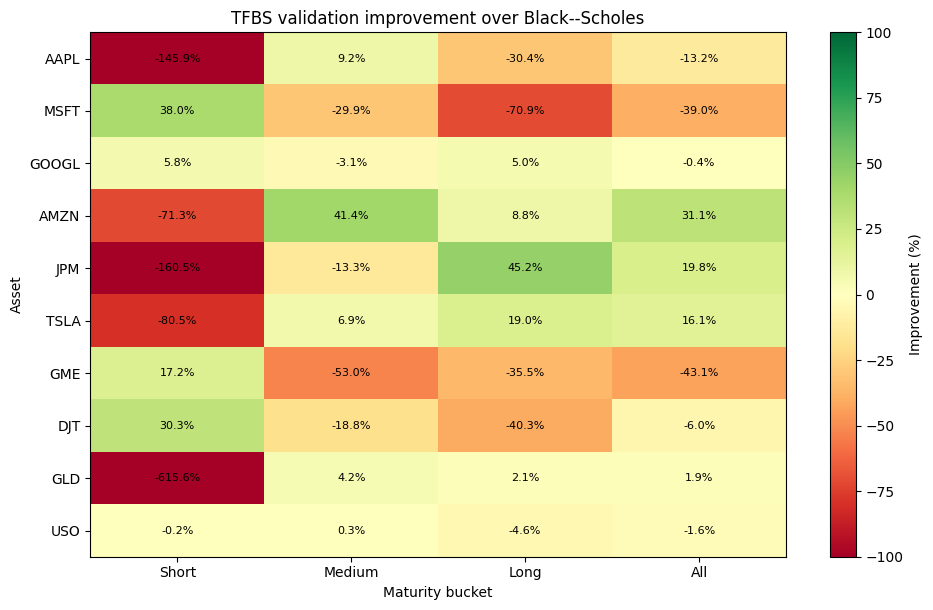

Saved: /content/tfbs_final_run/figures/fig7_1_cross_asset_improvement_heatmap.pdf
Saved: /content/tfbs_final_run/figures/fig7_1_cross_asset_improvement_heatmap.png


In [ ]:
# @title
# ============================================================
# 4-B. Figure 7.1: Cross-asset improvement heatmap
# ============================================================

def plot_improvement_heatmap(
    imp_table,
    filename="fig7_1_cross_asset_improvement_heatmap",
    clip_abs=100,
):
    data = imp_table[["Short", "Medium", "Long", "All"]].copy()

    fig, ax = plt.subplots(figsize=(9.8, 6.2))

    im = ax.imshow(
        data.to_numpy(dtype=float),
        aspect="auto",
        vmin=-clip_abs,
        vmax=clip_abs,
        cmap="RdYlGn",
    )

    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_xticklabels(data.columns)

    ax.set_yticks(np.arange(data.shape[0]))
    ax.set_yticklabels(data.index)

    ax.set_title("TFBS validation improvement over Black--Scholes")
    ax.set_xlabel("Maturity bucket")
    ax.set_ylabel("Asset")

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data.iloc[i, j]
            if np.isfinite(val):
                ax.text(
                    j,
                    i,
                    f"{val:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Improvement (%)")

    plt.tight_layout()

    pdf_path = os.path.join(FIGDIR, filename + ".pdf")
    png_path = os.path.join(FIGDIR, filename + ".png")

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", pdf_path)
    print("Saved:", png_path)


plot_improvement_heatmap(imp_table)

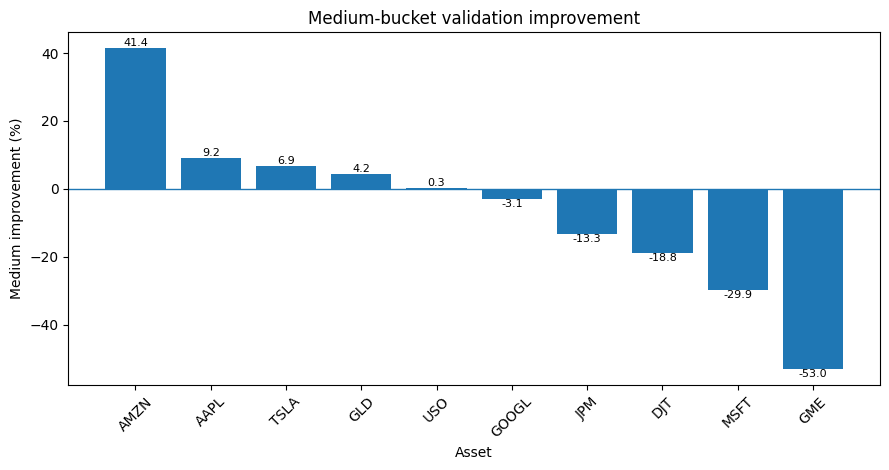

Saved: /content/tfbs_final_run/figures/fig7_2_medium_improvement.pdf
Saved: /content/tfbs_final_run/figures/fig7_2_medium_improvement.png


In [ ]:
# @title
# ============================================================
# 4-C. Figure 7.2: Medium-bucket improvement
# ============================================================

def plot_medium_improvement(imp_table, filename="fig7_2_medium_improvement"):
    data = imp_table[["Medium"]].copy()
    data = data.sort_values("Medium", ascending=False)

    fig, ax = plt.subplots(figsize=(9.0, 4.8))

    ax.bar(data.index, data["Medium"])
    ax.axhline(0, linewidth=1)

    ax.set_title("Medium-bucket validation improvement")
    ax.set_ylabel("Medium improvement (%)")
    ax.set_xlabel("Asset")
    ax.tick_params(axis="x", rotation=45)

    for i, val in enumerate(data["Medium"]):
        if np.isfinite(val):
            ax.text(
                i,
                val,
                f"{val:.1f}",
                ha="center",
                va="bottom" if val >= 0 else "top",
                fontsize=8,
            )

    plt.tight_layout()

    pdf_path = os.path.join(FIGDIR, filename + ".pdf")
    png_path = os.path.join(FIGDIR, filename + ".png")

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", pdf_path)
    print("Saved:", png_path)


plot_medium_improvement(imp_table)

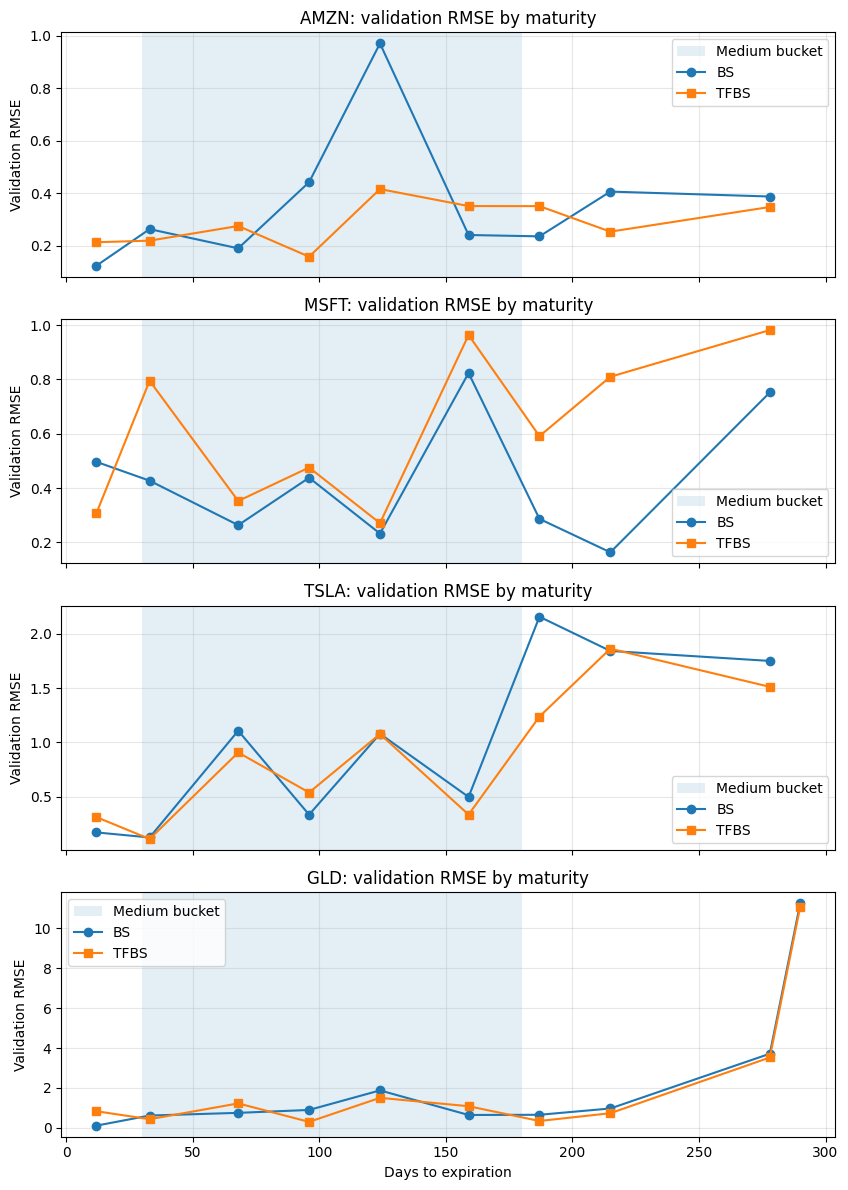

Saved: /content/tfbs_final_run/figures/fig7_3_selected_rmse_term_structures.pdf
Saved: /content/tfbs_final_run/figures/fig7_3_selected_rmse_term_structures.png


In [ ]:
# @title
# ============================================================
# 4-D. Figure 7.3: Selected RMSE term structures
# ============================================================

SELECTED_ASSETS = ["AMZN", "MSFT", "TSLA", "GLD"]


def plot_rmse_term_structure_selected(
    expiry_df,
    tickers=SELECTED_ASSETS,
    filename="fig7_3_selected_rmse_term_structures",
    short_days=30,
    medium_days=180,
):
    tickers = [t for t in tickers if t in set(expiry_df["ticker"])]

    if not tickers:
        print("No selected tickers found.")
        return

    n = len(tickers)
    fig, axes = plt.subplots(n, 1, figsize=(8.6, 3.0 * n), sharex=True)

    if n == 1:
        axes = [axes]

    for ax, tk in zip(axes, tickers):
        sub = expiry_df[expiry_df["ticker"] == tk].sort_values("T_days")

        ax.axvspan(short_days, medium_days, alpha=0.12, label="Medium bucket")
        ax.plot(sub["T_days"], sub["RMSE_val_BS"], marker="o", label="BS")
        ax.plot(sub["T_days"], sub["RMSE_val_TFBS"], marker="s", label="TFBS")

        ax.set_title(f"{tk}: validation RMSE by maturity")
        ax.set_ylabel("Validation RMSE")
        ax.grid(alpha=0.3)
        ax.legend()

    axes[-1].set_xlabel("Days to expiration")

    plt.tight_layout()

    pdf_path = os.path.join(FIGDIR, filename + ".pdf")
    png_path = os.path.join(FIGDIR, filename + ".png")

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", pdf_path)
    print("Saved:", png_path)


plot_rmse_term_structure_selected(expiry_final)

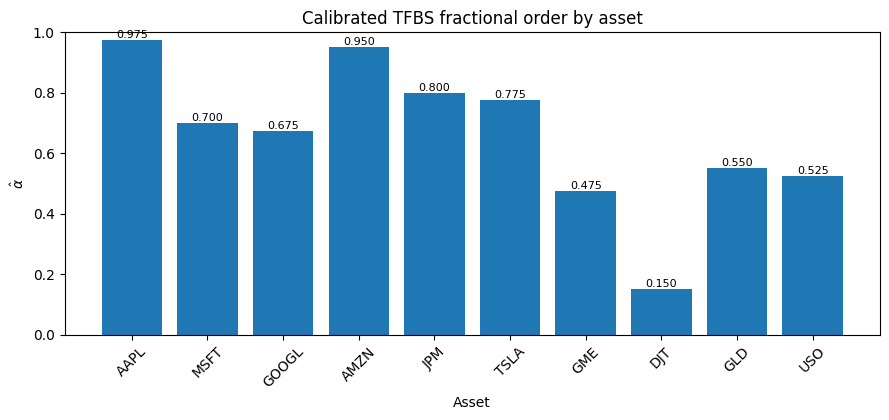

Saved: /content/tfbs_final_run/figures/fig7_4a_alpha_by_asset.pdf
Saved: /content/tfbs_final_run/figures/fig7_4a_alpha_by_asset.png


In [ ]:
# @title
# ============================================================
# 4-E. Figure 7.4a: Calibrated alpha by asset
# ============================================================

def plot_alpha_by_asset(expiry_df, filename="fig7_4a_alpha_by_asset"):
    if "alpha" not in expiry_df.columns:
        print("No alpha column found in expiry_df.")
        print("Available columns:", expiry_df.columns.tolist())
        return

    alpha = (
        expiry_df
        .groupby("ticker")["alpha"]
        .first()
        .reindex([a for a in ASSET_ORDER if a in set(expiry_df["ticker"])])
        .dropna()
    )

    fig, ax = plt.subplots(figsize=(9.0, 4.3))

    ax.bar(alpha.index, alpha.values)
    ax.set_ylim(0, 1)
    ax.set_title("Calibrated TFBS fractional order by asset")
    ax.set_ylabel(r"$\hat{\alpha}$")
    ax.set_xlabel("Asset")
    ax.tick_params(axis="x", rotation=45)

    for i, val in enumerate(alpha.values):
        ax.text(i, val, f"{val:.3f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()

    pdf_path = os.path.join(FIGDIR, filename + ".pdf")
    png_path = os.path.join(FIGDIR, filename + ".png")

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", pdf_path)
    print("Saved:", png_path)


plot_alpha_by_asset(expiry_final)

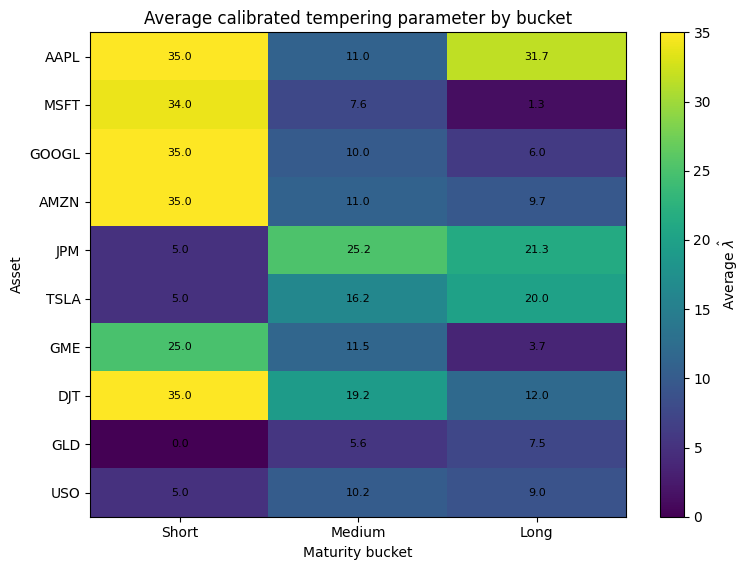

Saved: /content/tfbs_final_run/figures/fig7_4b_lambda_bucket_heatmap.pdf
Saved: /content/tfbs_final_run/figures/fig7_4b_lambda_bucket_heatmap.png


In [ ]:
# @title
# ============================================================
# 4-F. Figure 7.4b: Average lambda by maturity bucket
# ============================================================

def plot_lambda_bucket_heatmap(expiry_df, filename="fig7_4b_lambda_bucket_heatmap"):
    if "best_lambda_TFBS" not in expiry_df.columns:
        print("No best_lambda_TFBS column found.")
        print("Available columns:", expiry_df.columns.tolist())
        return

    data = (
        expiry_df
        .groupby(["ticker", "bucket"])["best_lambda_TFBS"]
        .mean()
        .unstack("bucket")
    )

    available_assets = [a for a in ASSET_ORDER if a in data.index]
    data = data.reindex(available_assets)

    for col in ["Short", "Medium", "Long"]:
        if col not in data.columns:
            data[col] = np.nan

    data = data[["Short", "Medium", "Long"]]

    fig, ax = plt.subplots(figsize=(7.8, 5.8))

    im = ax.imshow(data.to_numpy(dtype=float), aspect="auto")

    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_xticklabels(data.columns)

    ax.set_yticks(np.arange(data.shape[0]))
    ax.set_yticklabels(data.index)

    ax.set_title("Average calibrated tempering parameter by bucket")
    ax.set_xlabel("Maturity bucket")
    ax.set_ylabel("Asset")

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data.iloc[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"Average $\hat{\lambda}$")

    plt.tight_layout()

    pdf_path = os.path.join(FIGDIR, filename + ".pdf")
    png_path = os.path.join(FIGDIR, filename + ".png")

    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", pdf_path)
    print("Saved:", png_path)


plot_lambda_bucket_heatmap(expiry_final)

In [ ]:
# @title
# ============================================================
# 4-G. Print LaTeX figure snippets
# ============================================================

latex_snippets = r"""
% Preamble:
% \usepackage{graphicx}
% \usepackage{subcaption}
% \graphicspath{{figures/}}

\begin{figure}[htbp]
\centering
\includegraphics[width=0.92\textwidth]{fig7_1_cross_asset_improvement_heatmap.pdf}
\caption{Validation RMSE improvement of TFBS relative to Black--Scholes across assets and maturity buckets. The color scale is clipped at $\pm100\%$ for readability.}
\label{fig:cross_asset_improvement_heatmap}
\end{figure}

\begin{figure}[htbp]
\centering
\includegraphics[width=0.85\textwidth]{fig7_2_medium_improvement.pdf}
\caption{Medium-bucket validation improvement of TFBS relative to Black--Scholes.}
\label{fig:medium_improvement}
\end{figure}

\begin{figure}[htbp]
\centering
\includegraphics[width=0.9\textwidth]{fig7_3_selected_rmse_term_structures.pdf}
\caption{Validation RMSE term structures for selected representative assets. The shaded region denotes the medium-maturity bucket.}
\label{fig:selected_rmse_term_structures}
\end{figure}

\begin{figure}[htbp]
\centering
\begin{subfigure}{0.48\textwidth}
\centering
\includegraphics[width=\textwidth]{fig7_4a_alpha_by_asset.pdf}
\caption{Calibrated fractional order.}
\end{subfigure}
\hfill
\begin{subfigure}{0.48\textwidth}
\centering
\includegraphics[width=\textwidth]{fig7_4b_lambda_bucket_heatmap.pdf}
\caption{Average tempering parameter by maturity bucket.}
\end{subfigure}
\caption{TFBS parameter signatures across assets.}
\label{fig:parameter_signatures}
\end{figure}
"""

print(latex_snippets)


% Preamble:
% \usepackage{graphicx}
% \usepackage{subcaption}
% \graphicspath{{figures/}}

\begin{figure}[htbp]
\centering
\includegraphics[width=0.92\textwidth]{fig7_1_cross_asset_improvement_heatmap.pdf}
\caption{Validation RMSE improvement of TFBS relative to Black--Scholes across assets and maturity buckets. The color scale is clipped at $\pm100\%$ for readability.}
\label{fig:cross_asset_improvement_heatmap}
\end{figure}

\begin{figure}[htbp]
\centering
\includegraphics[width=0.85\textwidth]{fig7_2_medium_improvement.pdf}
\caption{Medium-bucket validation improvement of TFBS relative to Black--Scholes.}
\label{fig:medium_improvement}
\end{figure}

\begin{figure}[htbp]
\centering
\includegraphics[width=0.9\textwidth]{fig7_3_selected_rmse_term_structures.pdf}
\caption{Validation RMSE term structures for selected representative assets. The shaded region denotes the medium-maturity bucket.}
\label{fig:selected_rmse_term_structures}
\end{figure}

\begin{figure}[htbp]
\centering
\begin

In [ ]:
# @title
# ============================================================
# 4-H. Zip final results and figures
# ============================================================

try:
    from google.colab import files

    zip_base = "/content/tfbs_final_run_package"
    shutil.make_archive(zip_base, "zip", OUTDIR)

    files.download(zip_base + ".zip")

except Exception as exc:
    print("Could not use google.colab download.")
    print("Results are saved in:", OUTDIR)
    print("Error:", exc)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#--------------------8장------------------------